# 가설 — 판매자에 따라 지속적으로 갈리는 고객 만족

검증할 가설: **지속적으로 낮은 평가를 받는 판매자가 실재하며, 그 낮은 평가가 약속 위반에서
오는지 아닌지에 따라 처방이 달라진다.**

앞 노트북이 만족을 움직이는 것으로 찾은 것은 약속의 준수 여부였고, 처방도 주문 단위였다 —
들어오는 주문의 예상 도착일을 며칠 미룬다. 누구의 주문인지는 따지지 않는다.
이 가설이 묻는 것은 개입할 대상이 주문이 아니라 **판매자**일 수 있는가이다.

가설이 말하는 것은 둘.

1. 주문이 적어서 흩어진 것이 아니라, 평가가 진짜로 낮은 판매자가 있다
2. 그 낮은 평가가 약속 위반에서 오는지 아닌지에 따라 해야 할 일이 다르다

두 번째가 가르는 것은 문제의 존재가 아니라 처방의 종류다. 배송에서 오는 것이면 그 판매자의
예상 도착일을 더 미루는 것이 처방이고, 약속을 지킨 주문에서도 낮다면 날짜를 미뤄도 소용없어
다른 조치가 필요하다.

**검증 과정에서 나온 것 — 약속 위반을 자주 일으키는 판매자가 따로 있고, 예상 도착일을 판매자에 따라 달리 미룰 수 있다.**

조건 2 를 보는 과정에서 판정 대상의 위반율이 나머지보다 높게 나왔다. 판정 대상은 고객 만족도로 고른 판매자라,
위반을 자주 일으키는 판매자가 있는지는 위반을 기준으로 다시 골라야 답할 수 있다.
06 에서 예상 도착일을 시기별로 달리 미루는 정책은 주문 시점에 그 달이 급증 달인지 알 수 없어 상한으로 남았다.
누가 파는지는 주문 시점에 정해져 있다. 6 에서 이 차등을 다루고, 7 에서 주문 시점까지의 이력만으로 같은 판매자를 고를 수 있는지 확인한다.

고객 만족도는 05 에서 정한 대로 리뷰 점수(1 ~ 5)로 측정. 공용 표본과 축약 규칙도 05 를 따르며
뷰 `order_review` 를 그대로 사용.

**확인 항목**

- 판정 기준 — 무엇이 나오면 성립하고 무엇이 나오면 불성립인가 (1)
- 표본 — 05 공용 표본에 더 걸 조건과 그때 빠지는 규모, 판매자 귀속 규칙 (2)
- 전용 지표 — 판매자 단위 지표와 흔들림을 가르는 방법 (3)
- 조건 1 · 2 — 지속적으로 낮은 판매자가 있는가, 그 낮은 평가가 약속 위반에서 오는가 (4 ~ 5)
- 판매자 단위 약속 위반 — 위반을 자주 일으키는 판매자가 있는가, 그 판매자에게 더 미루면 1 점 주문이 얼마나 줄어드는가 (6)
- 이력으로 고른 판매자 — 이전 12 개월의 이력으로 고른 판매자가 이후에도 위반이 잦은가, 그 판매자에게 더 미루면 이후 기간에서 1 점 주문이 얼마나 줄어드는가 (7)

## 0. 연결

05 가 만든 뷰 `order_review` 를 사용하므로 05 실행 이후의 상태가 전제.
처음부터 다시 돌릴 때는 02 로 원본을 복원한 뒤 03 · 04 · 05 순서로 실행.

In [1]:
import duckdb

con = duckdb.connect('../olist.duckdb')
con.execute("SET enable_progress_bar = false");

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

FAST, MID, SLOW = '#3C6E9F', '#D9A05B', '#B3524B'

## 1. 판정 기준

**조건 1 — 지속적으로 낮은 판매자가 실재하는가.**

판매자별 평균 리뷰 점수의 95 % 구간을 잡고 그 상한이 전체 평균보다 낮은 판매자를 센다.
최소 주문 수는 따로 정하지 않는다.

- 성립 — 걸러진 판매자 수가 우연으로 기대되는 수를 뚜렷이 넘고,
  그 판매자들의 주문이 표본에서 무시할 수 없는 비중을 차지한다
- 불성립 — 걸러진 수가 우연으로 기대되는 수와 비슷하거나, 그 주문이 표본에서 차지하는 비중이 아주 작다

같은 점수만 받은 판매자는 표준편차가 0 이라 정규 근사 구간의 폭이 0 이 되므로,
평균의 구간과 함께 1 ~ 2 점 비율의 Wilson 구간을 본다. 둘 다 나쁜 쪽을 가리킬 때만 판정한다.

**조건 2 — 그 낮은 평가가 약속 위반에서 오는가.**

조건 1 을 통과한 판매자들의 주문 중 약속을 지킨 것만 놓고 같은 구간을 다시 잡는다.

- 배송 밖 요인 — 약속을 지킨 주문만 놓고 보아도 평균이 약속을 지킨 주문의 전체 평균보다 낮게 남는다.
  예상 도착일을 미루는 것으로는 해결되지 않으며 다른 조치가 필요하다
- 배송이 전부 — 약속을 지킨 주문만 보면 평균 근처로 올라온다.
  06 의 시뮬레이션을 이 판매자 집합에만 돌려 크기를 낸다

두 쪽이 섞여 나오면 판매자를 두 무리로 나눠 각각의 규모를 적는다.

## 2. 표본 — 공용 표본에 더 걸 조건

05 의 공용 표본 98,330 건에 이 가설에만 필요한 조건을 더한다.

공용 표본은 주문 99,441 건 전체에 두 조건을 걸어 만든 것이다.

- **2017-01 ~ 2018-08 구매** — 수집 구간 양 끝의 잘린 달을 뺌. 349 건 제외
- **리뷰 있음** — 만족을 리뷰 점수로 재므로 점수가 없는 주문을 뺌. 762 건 제외

리뷰가 여럿 달린 주문 545 건은 마지막에 작성된 리뷰 하나만 남겨 주문 하나에 점수 하나가 되게 했다.
뷰 `order_review` 의 한 행이 공용 표본의 주문 하나다.
주문 상태나 배송 여부는 걸지 않았으므로 배송되지 않은 주문도 들어 있다.

여기에 더하는 조건은 셋.

- **배송 완료** — 조건 2 가 약속 준수 여부를 쓰므로 배송을 겪고 완료 시각이 남은 주문이어야 함
- **품목 기록 있음** — 판매자는 `order_items` 를 거쳐야 알 수 있고, 품목이 없는 주문에는 붙일 수 없음
- **판매자 한 곳** — 한 주문에 판매자가 여럿이면 그 점수를 누구에게 돌릴지 정할 수 없음

조건을 누적해 걸며 남는 행을 집계. 단계마다 줄어드는 폭이 그 조건에서 빠지는 주문의 규모.

In [3]:
con.execute("""
SELECT '1. 공용 표본' AS step,
       COUNT(*)      AS rows
FROM order_review

UNION ALL
SELECT '2. + 배송 완료', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL

UNION ALL
SELECT '3. + 품목 기록 있음', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND EXISTS (SELECT 1 FROM order_items AS i WHERE i.order_id = o.order_id)

UNION ALL
SELECT '4. + 판매자 한 곳', COUNT(*)
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND (SELECT COUNT(DISTINCT i.seller_id)
       FROM order_items AS i
       WHERE i.order_id = o.order_id) = 1

ORDER BY step
""").df()

,step,rows
0,1. 공용 표본,98330
1,2. + 배송 완료,95560
2,3. + 품목 기록 있음,95560
3,4. + 판매자 한 곳,94302


공용 표본 98,330 건에서 94,302 건이 남는다. 전체의 95.9 %.

- **배송 미완료 2,770 건** — 배송을 겪지 않아 약속 준수를 물을 수 없는 주문
- **품목 기록 없음 0 건** — 03 에서 품목이 없다고 확인한 주문은 배송된 것이 하나도 없어
  앞 조건에서 이미 전부 빠졌다. 이 조건은 결과적으로 아무것도 걸러내지 않는다
- **판매자 여럿 1,258 건** — 배송 완료분 95,560 건의 1.32 %

판매자가 여럿인 주문을 버리는 선택이 타당한지 규모로 확인한다.
버리는 대신 주문을 판매자마다 복제해 같은 점수를 나눠 붙이는 방법도 있으나,
그러면 한 주문의 점수가 여러 번 계수되고 그 점수를 누가 만들었는지도 알 수 없다.

In [4]:
con.execute("""
WITH base AS (
    SELECT o.order_id
    FROM order_review AS o
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
),
per_order AS (
    SELECT b.order_id,
           COUNT(DISTINCT i.seller_id) AS sellers,
           COUNT(*)                    AS items
    FROM base        AS b
    JOIN order_items AS i ON i.order_id = b.order_id
    GROUP BY b.order_id
)
SELECT sellers,
       COUNT(*)                                           AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct,
       SUM(items)                                         AS items
FROM per_order
GROUP BY sellers
ORDER BY sellers
""").df()

,sellers,orders,pct,items
0,1,94302,98.68,105997.0
1,2,1199,1.25,2825.0
2,3,54,0.06,202.0
3,4,3,0.00,12.0
4,5,2,0.00,13.0


배송이 완료된 95,560 건 중 판매자가 한 곳인 주문이 94,302 건으로 98.68 %.
둘인 주문이 1,199 건(1.25 %), 셋 54 건, 넷 3 건, 다섯 2 건.

버려지는 것이 1.32 % 라 판매자 귀속 규칙에서 잃는 표본이 거의 없다.
주문을 판매자마다 복제해 점수를 나눠 붙이는 방법을 쓸 이유가 없다.

## 3. 전용 지표

2 의 조건을 적용한 결과를 뷰 `seller_review` 로 고정한다. 주문 하나에 판매자 하나가 붙고,
05 의 점수와 06 이 쓴 약속 대비 값을 함께 담아 조건 2 에서 약속 준수로 나눌 수 있게 한다.

판매자 단위 지표는 셋.

- `orders` — 그 판매자의 주문 수
- `avg_score` — 평균 리뷰 점수. `ci_high` 는 정규 근사 95 % 구간의 상한
- `low_rate` — 1 ~ 2 점 비율. `wilson_low` 는 그 비율의 Wilson 95 % 구간 하한

In [5]:
con.execute("""
CREATE OR REPLACE VIEW seller_review AS
SELECT o.order_id,
       (SELECT MIN(i.seller_id)
        FROM order_items AS i
        WHERE i.order_id = o.order_id) AS seller_id,
       o.customer_state,
       o.order_purchase_timestamp,
       o.delivery_days,
       o.days_vs_promise,
       o.review_score
FROM order_review AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND (SELECT COUNT(DISTINCT i.seller_id)
       FROM order_items AS i
       WHERE i.order_id = o.order_id) = 1
""")

con.execute("""
SELECT COUNT(*)                   AS rows,
       COUNT(DISTINCT order_id)   AS orders,
       COUNT(DISTINCT seller_id)  AS sellers,
       ROUND(AVG(review_score), 4) AS avg_score,
       ROUND(AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END), 4) AS low_rate,
       COUNT(*) FILTER (seller_id IS NULL) AS null_seller
FROM seller_review
""").df()

,rows,orders,sellers,avg_score,low_rate,null_seller
0,94302,94302,2922,4.1735,0.1234,0


지표를 판매자마다 계산하고 규모별로 몇 곳이 어느 폭을 갖는지 확인한다.
구간의 폭이 주문 수에 따라 어떻게 줄어드는지가 판정에서 무엇이 걸러질지를 정한다.

In [6]:
con.execute("""
WITH per_seller AS (
    SELECT seller_id,
           COUNT(*)                                              AS orders,
           AVG(review_score)                                     AS avg_score,
           STDDEV_SAMP(review_score)                             AS sd,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_rate
    FROM seller_review
    GROUP BY seller_id
)
SELECT CASE WHEN orders >= 100 THEN '1. 100건 이상'
            WHEN orders >=  50 THEN '2. 50~99건'
            WHEN orders >=  20 THEN '3. 20~49건'
            WHEN orders >=  10 THEN '4. 10~19건'
            WHEN orders >=   5 THEN '5. 5~9건'
            ELSE                    '6. 5건 미만' END              AS bucket,
       COUNT(*)                                                   AS sellers,
       SUM(orders)                                                AS orders,
       ROUND(100.0 * SUM(orders) / SUM(SUM(orders)) OVER (), 2)    AS pct_orders,
       ROUND(AVG(avg_score), 3)                                   AS avg_score,
       ROUND(AVG(1.96 * sd / SQRT(orders)), 3)                     AS avg_ci_halfwidth,
       COUNT(*) FILTER (sd = 0 OR sd IS NULL)                      AS sd_zero
FROM per_seller
GROUP BY bucket
ORDER BY bucket
""").df()

,bucket,sellers,orders,pct_orders,avg_score,avg_ci_halfwidth,sd_zero
0,1. 100건 이상,200,56016.0,59.40,4.160,0.175,0
1,2. 50~99건,208,14650.0,15.54,4.205,0.284,0
2,3. 20~49건,376,11895.0,12.61,4.227,0.420,1
3,4. 10~19건,426,5839.0,6.19,4.218,0.620,1
4,5. 5~9건,520,3513.0,3.73,4.255,0.789,42
5,6. 5건 미만,1192,2389.0,2.53,4.220,1.041,723


뷰 `seller_review` 는 94,302 행에 판매자 2,922 곳, 평균 점수 4.1735, 1 ~ 2 점 비율 0.1234.
`seller_id` 가 비는 행은 없다.

**규모가 크게 치우쳐 있다.** 주문 100 건 이상인 판매자가 200 곳뿐인데 그들이 주문의 59.40 % 를
차지하고, 5 건 미만인 판매자는 1,192 곳으로 판매자의 40.8 % 인데 주문은 2.53 % 다.

**규모에 따라 걸리는 문턱이 다르다.** 평균 반폭은 100 건 이상에서 0.175, 50 ~ 99 건 0.284,
20 ~ 49 건 0.420, 10 ~ 19 건 0.620, 5 ~ 9 건 0.789, 5 건 미만 1.041.
전체 평균 4.17 에서 이 반폭을 빼면, 100 건 이상인 판매자는 평균이 4.00 아래일 때,
5 건 미만인 판매자는 3.13 아래일 때 상한이 전체 평균보다 낮아진다.

**표준편차가 0 인 판매자가 767 곳이다.** 5 건 미만에 723 곳, 5 ~ 9 건에 42 곳, 그 위로 2 곳.
판매자의 26.2 % 가 모든 주문에서 같은 점수를 받았다. 이들은 반폭이 0 이라 구간 상한이 평균과 같다.
1 에서 평균의 구간과 함께 1 ~ 2 점 비율의 Wilson 구간을 보기로 한 것은 이 경우 때문이다.

고객 만족도가 전체와 차이 없는 판매자라도 받은 리뷰 점수는 주문마다 달라지므로,
판매자마다 같은 기준을 적용하면 그중 일부는 우연히 기준에 걸린다. 그 수는 4 에서 센다.

## 4. 조건 1 — 지속적으로 낮은 판매자가 있는가

판매자 단위 지표와 두 판정 플래그를 뷰 `seller_metric` 으로 고정한다.
기준선인 전체 평균과 전체 1 ~ 2 점 비율도 뷰 안에서 표본으로부터 직접 잡으므로
뒤 절에서 같은 계산을 다시 쓰지 않는다.

- `hit_mean` — 평균의 95 % 구간 상한이 전체 평균보다 낮음
- `hit_low` — 1 ~ 2 점 비율의 Wilson 95 % 구간 하한이 전체 1 ~ 2 점 비율보다 높음
- `flagged` — 둘 다. 1 에서 정한 판정 대상

주문이 한 건인 판매자는 표준편차가 없어 `hit_mean` 이 참도 거짓도 아니다.
`flagged` 는 그 경우를 거짓으로 접어 판정에서 뺀다.

주문이 둘 이상이라도 같은 점수만 받았으면 표준편차가 0 이라 구간의 폭이 0 이 된다.
`ci_high` 가 평균 그 자체이므로 `hit_mean` 은 이들에게 검정이 아니라 평균이 기준선 아래인지를
묻는 것이 되고, 두 기준을 함께 요구하는 `flagged` 도 이 경우는 걸러내지 못한다.

In [7]:
con.execute("""
CREATE OR REPLACE VIEW seller_metric AS
WITH base AS (
    SELECT AVG(review_score)                                      AS avg_all,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_all
    FROM seller_review
),
per_seller AS (
    SELECT seller_id,
           COUNT(*)                                           AS orders,
           AVG(review_score)                                  AS avg_score,
           STDDEV_SAMP(review_score)                          AS sd,
           SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS low_n,
           COUNT(*) FILTER (days_vs_promise > 0)              AS late_n
    FROM seller_review
    GROUP BY seller_id
),
calc AS (
    SELECT p.seller_id,
           p.orders,
           p.avg_score,
           p.avg_score + 1.96 * p.sd / SQRT(p.orders) AS ci_high,
           1.0 * p.low_n  / p.orders                  AS low_rate,
           ((1.0 * p.low_n / p.orders + 1.9208 / p.orders)
            - 1.96 * SQRT((1.0 * p.low_n / p.orders)
                          * (1 - 1.0 * p.low_n / p.orders) / p.orders
                          + 0.9604 / (p.orders * p.orders)))
           / (1 + 3.8416 / p.orders)                  AS wilson_low,
           1.0 * p.late_n / p.orders                  AS late_rate,
           b.avg_all,
           b.low_all
    FROM per_seller AS p
    CROSS JOIN base AS b
)
SELECT seller_id, orders, avg_score, ci_high, low_rate, wilson_low, late_rate,
       ci_high    < avg_all AS hit_mean,
       wilson_low > low_all AS hit_low,
       COALESCE(ci_high < avg_all AND wilson_low > low_all, FALSE) AS flagged
FROM calc
""")

con.execute("""
SELECT COUNT(*)                     AS sellers,
       ROUND(MIN(avg_score), 3)     AS min_avg,
       ROUND(MAX(avg_score), 3)     AS max_avg,
       COUNT(*) FILTER (ci_high IS NULL) AS no_interval
FROM seller_metric
""").df()

,sellers,min_avg,max_avg,no_interval
0,2922,1.0,5.0,526


In [8]:
con.execute("""
SELECT '1. 평균 구간 상한이 전체 평균보다 낮음'            AS rule,
       COUNT(*)                                            AS sellers,
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric
                           WHERE ci_high IS NOT NULL))
            AS BIGINT)                                     AS chance_max,
       CAST(SUM(orders) AS BIGINT)                         AS orders,
       ROUND(100.0 * SUM(orders)
             / (SELECT SUM(orders) FROM seller_metric), 2) AS pct_orders,
       ROUND(AVG(avg_score), 3)                            AS avg_score
FROM seller_metric WHERE hit_mean

UNION ALL
SELECT '2. Wilson 하한이 전체 1~2점 비율보다 높음',
       COUNT(*),
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric)) AS BIGINT),
       CAST(SUM(orders) AS BIGINT),
       ROUND(100.0 * SUM(orders) / (SELECT SUM(orders) FROM seller_metric), 2),
       ROUND(AVG(avg_score), 3)
FROM seller_metric WHERE hit_low

UNION ALL
SELECT '3. 둘 다 — 판정 대상',
       COUNT(*),
       CAST(ROUND(0.025 * (SELECT COUNT(*) FROM seller_metric
                           WHERE ci_high IS NOT NULL)) AS BIGINT),
       CAST(SUM(orders) AS BIGINT),
       ROUND(100.0 * SUM(orders) / (SELECT SUM(orders) FROM seller_metric), 2),
       ROUND(AVG(avg_score), 3)
FROM seller_metric WHERE flagged

ORDER BY rule
""").df()

,rule,sellers,chance_max,orders,pct_orders,avg_score
0,1. 평균 구간 상한이 전체 평균보다 낮음,130,60,16188,17.17,3.155
1,2. Wilson 하한이 전체 1~2점 비율보다 높음,226,73,16142,17.12,2.577
2,3. 둘 다 — 판정 대상,94,60,13700,14.53,3.068


`chance_max` 는 기준을 적용한 판매자 수에 2.5 % 를 곱한 값이다. 2.5 % 는 주문이 많을 때 성립하는 값이고,
주문이 적으면 1 ~ 2 점 건수가 몇 가지뿐이라 실제로 걸리는 확률이 그와 다르다.
고객 만족도가 전체와 차이 없는 판매자, 즉 주문마다 1 ~ 2 점을 받을 확률이 전체 비율 0.123 과 같은 판매자라도
주문이 한 건이면 12.3 % 확률로 1 ~ 2 점을 받고, 그때 Wilson 하한이 0.207 이라 기준에 걸린다.

Wilson 기준에 대해서는 이 확률을 판매자마다 이항분포로 직접 구해 더한다.

1. 판매자가 주문마다 1 ~ 2 점을 받을 확률이 전체 비율 $p$ 와 같다고 둔다.
   고객 만족도가 전체와 차이 없는 판매자를 가정하는 것이다
2. 주문 수 $n$ 에서 1 ~ 2 점이 $k$ 건 나올 확률을 $k = 0 \sim n$ 에 대해 모두 계산한다

   $$P(k) = \binom{n}{k} p^k (1-p)^{n-k}$$

   주문이 수천 건이면 $\binom{n}{k}$ 가 너무 커지므로 로그로 계산한다.
   $\ln \binom{n}{k} = \ln\Gamma(n+1) - \ln\Gamma(k+1) - \ln\Gamma(n-k+1)$ 이고 SQL 의 `LGAMMA` 가 $\ln\Gamma$ 다
3. 각 $k$ 에서 Wilson 하한을 구해 $p$ 를 넘는 $k$ 의 확률만 합한다. $\hat p = k/n$, $z = 1.96$ 일 때

   $$\text{하한} = \frac{\hat p + \frac{z^2}{2n} - z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

   이 합이 주문 수 $n$ 인 판매자가 우연으로 걸릴 확률이다
4. 그 확률을 판매자 전체에 걸쳐 더한다

열은 다음과 같다.

- `hit_low` — Wilson 기준에 실제로 걸린 판매자 수
- `chance_max` — 판매자 수 × 2.5 %
- `chance_exact` — 3 의 확률을 판매자마다 더한 값. 우연으로 걸리는 판매자 수의 기대치
- `chance_pct` — 그 규모에서 판매자 한 곳이 우연으로 걸릴 평균 확률
- `ratio` — `hit_low` ÷ `chance_exact`. 1 이면 우연으로 기대되는 만큼만 걸린 것
- `pmf_err` — $n$ 마다 $P(k)$ 를 전부 더한 값이 1 에서 벗어난 최대 폭. 계산 검산용

In [9]:
con.execute("""
WITH base AS (
    SELECT AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS p
    FROM seller_review
),
sizes AS (
    SELECT DISTINCT orders AS n
    FROM seller_metric
),
grid AS (
    SELECT n, UNNEST(generate_series(0, n)) AS k
    FROM sizes
),
prob AS (
    SELECT g.n,
           g.k,
           EXP(LGAMMA(g.n + 1) - LGAMMA(g.k + 1) - LGAMMA(g.n - g.k + 1)
               + g.k * LN(b.p) + (g.n - g.k) * LN(1 - b.p))          AS pmf,
           ((1.0 * g.k / g.n + 1.9208 / g.n)
            - 1.96 * SQRT((1.0 * g.k / g.n) * (1 - 1.0 * g.k / g.n) / g.n
                          + 0.9604 / (g.n * g.n)))
           / (1 + 3.8416 / g.n) > b.p                                  AS hit
    FROM grid AS g
    CROSS JOIN base AS b
),
per_n AS (
    SELECT n,
           COALESCE(SUM(pmf) FILTER (hit), 0) AS p_hit,
           ABS(SUM(pmf) - 1)                  AS pmf_err
    FROM prob
    GROUP BY n
),
per_seller AS (
    SELECT CASE WHEN m.orders >= 100 THEN '1. 100건 이상'
                WHEN m.orders >=  50 THEN '2. 50~99건'
                WHEN m.orders >=  20 THEN '3. 20~49건'
                WHEN m.orders >=  10 THEN '4. 10~19건'
                WHEN m.orders >=   5 THEN '5. 5~9건'
                ELSE                      '6. 5건 미만' END AS bucket,
           m.hit_low,
           p.p_hit,
           p.pmf_err
    FROM seller_metric AS m
    JOIN per_n         AS p ON p.n = m.orders
)
SELECT COALESCE(bucket, '0. 전체')                     AS bucket,
       COUNT(*)                                        AS sellers,
       COUNT(*) FILTER (hit_low)                       AS hit_low,
       ROUND(0.025 * COUNT(*), 1)                      AS chance_max,
       ROUND(SUM(p_hit), 1)                            AS chance_exact,
       ROUND(100.0 * AVG(p_hit), 2)                    AS chance_pct,
       ROUND(COUNT(*) FILTER (hit_low) / SUM(p_hit), 2) AS ratio,
       MAX(pmf_err)                                    AS pmf_err
FROM per_seller
GROUP BY GROUPING SETS ((bucket), ())
ORDER BY bucket
""").df()

,bucket,sellers,hit_low,chance_max,chance_exact,chance_pct,ratio,pmf_err
0,0. 전체,2922,226,73.1,150.1,5.14,1.51,1.605827e-12
1,1. 100건 이상,200,36,5.0,5.8,2.92,6.16,1.605827e-12
2,2. 50~99건,208,21,5.2,6.7,3.21,3.15,6.916689e-14
3,3. 20~49건,376,21,9.4,13.2,3.51,1.59,1.487699e-14
4,4. 10~19건,426,25,10.7,17.0,4.00,1.47,1.998401e-15
5,5. 5~9건,520,27,13.0,16.9,3.24,1.60,1.110223e-15
6,6. 5건 미만,1192,96,29.8,90.5,7.59,1.06,1.110223e-16


**Wilson 기준의 우연 기대치는 150.1 곳으로, 판매자 수에 2.5 % 를 곱한 73.1 곳의 두 배가 넘는다.**
판매자 한 곳이 우연으로 걸릴 확률이 평균 5.14 % 이고, 주문 5 건 미만에서는 7.59 % 다.
확률을 모두 더한 값이 1 에서 벗어난 폭은 최대 1.6 × 10⁻¹² 로 계산 오차는 무시할 수 있다.

실제로 걸린 226 곳은 기대치의 1.51 배다. 규모별로 갈린다. 100 건 이상에서 36 곳이 걸려 기대치 5.8 곳의 6.16 배,
50 ~ 99 건에서 3.15 배이고, 20 ~ 49 건 1.59 배, 10 ~ 19 건 1.47 배, 5 ~ 9 건 1.60 배로 내려간다.
5 건 미만에서는 96 곳이 걸렸는데 기대치가 90.5 곳이라 1.06 배로, 걸린 수 대부분이 우연으로 설명된다.

주문 100 건 이상에서는 기대치 5.8 곳이 2.5 % 로 잡은 5.0 곳과 거의 같다.
주문이 많은 판매자에서는 2.5 % 기준이 그대로 성립한다.

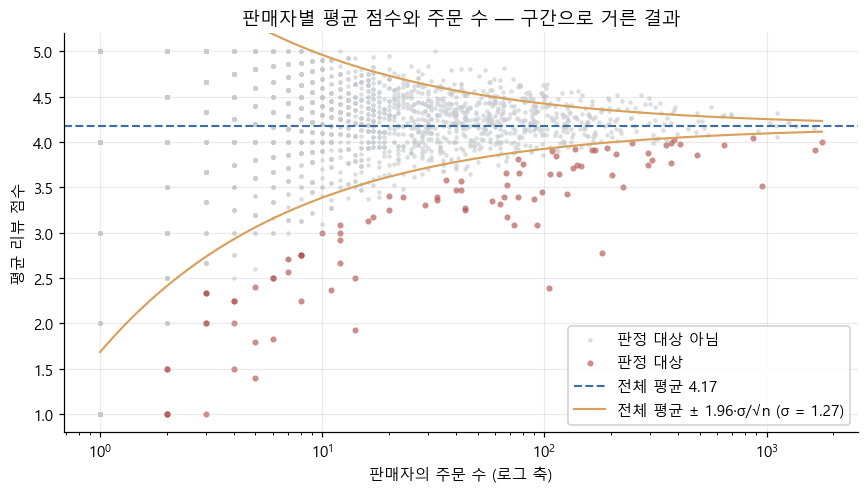

In [10]:
import numpy as np

d = con.execute("SELECT orders, avg_score, flagged FROM seller_metric ORDER BY flagged").df()
base, sd_all, n_max = con.execute("""
SELECT AVG(review_score),
       STDDEV_SAMP(review_score),
       (SELECT MAX(orders) FROM seller_metric)
FROM seller_review
""").fetchone()

n = np.logspace(0, np.log10(n_max), 200)
half = 1.96 * sd_all / np.sqrt(n)

fig, ax = plt.subplots(figsize=(8, 4.6))
for keep, color, size, label in [(False, '#C9CDD2', 9, '판정 대상 아님'),
                                 (True, SLOW, 16, '판정 대상')]:
    s = d[d['flagged'] == keep]
    ax.scatter(s['orders'], s['avg_score'], s=size, c=color, alpha=0.65,
               linewidths=0, label=label)
ax.axhline(base, color=FAST, lw=1.4, ls='--', label=f'전체 평균 {base:.2f}')
ax.plot(n, base - half, color=MID, lw=1.4, label=f'전체 평균 ± 1.96·σ/√n (σ = {sd_all:.2f})')
ax.plot(n, base + half, color=MID, lw=1.4)
ax.set_xscale('log')
ax.set_ylim(0.8, 5.2)
ax.set_xlabel('판매자의 주문 수 (로그 축)')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('판매자별 평균 점수와 주문 수 — 구간으로 거른 결과')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

산점도의 선은 전체 표준편차 하나로 그린 경계이고, 판정은 판매자 자신의 표준편차로 잡은 구간과
1 ~ 2 점 비율의 Wilson 구간을 함께 쓴다. 그래서 선 아래에 있어도 판정 대상이 아닌 판매자가 생긴다.
주문이 둘 이상이면서 선 아래에 있는 판정 대상이 아닌 판매자를 두 기준 중 어디서 빠졌는지로 나눠 센다.

In [11]:
con.execute("""
WITH b AS (
    SELECT AVG(review_score)                                      AS avg_all,
           STDDEV_SAMP(review_score)                              AS sd_all,
           AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END) AS low_all
    FROM seller_review
),
own AS (
    SELECT seller_id, STDDEV_SAMP(review_score) AS sd_own
    FROM seller_review
    GROUP BY seller_id
),
below AS (
    SELECT m.*, o.sd_own, b.sd_all, b.low_all
    FROM seller_metric AS m
    JOIN own           AS o USING (seller_id)
    CROSS JOIN b
    WHERE NOT m.flagged
      AND m.orders >= 2
      AND m.avg_score < b.avg_all - 1.96 * b.sd_all / SQRT(m.orders)
)
SELECT CASE WHEN NOT hit_mean AND     hit_low THEN '1. 평균 구간만 불충족'
            WHEN     hit_mean AND NOT hit_low THEN '2. Wilson 구간만 불충족'
            ELSE                                   '3. 둘 다 불충족' END AS reason,
       COUNT(*)                          AS sellers,
       MIN(orders)                       AS min_orders,
       MAX(orders)                       AS max_orders,
       CAST(SUM(orders) AS BIGINT)       AS orders,
       ROUND(AVG(avg_score), 3)          AS avg_score,
       ROUND(AVG(sd_own), 3)             AS sd_own,
       ROUND(MIN(sd_all), 3)             AS sd_all,
       ROUND(AVG(low_rate), 3)           AS low_rate,
       ROUND(MIN(low_all), 3)            AS low_all
FROM below
GROUP BY reason
ORDER BY reason
""").df()

,reason,sellers,min_orders,max_orders,orders,avg_score,sd_own,sd_all,low_rate,low_all
0,1. 평균 구간만 불충족,40,3,313,937,3.145,1.845,1.27,0.427,0.123
1,2. Wilson 구간만 불충족,22,2,1110,2457,3.105,1.389,1.27,0.299,0.123
2,3. 둘 다 불충족,21,3,321,1176,3.520,1.544,1.27,0.239,0.123


주문이 둘 이상이면서 선 아래에 있는데 판정 대상이 아닌 판매자는 83 곳, 주문 4,570 건이다.

- **평균 구간만 불충족 40 곳, 주문 937 건.** 자기 표준편차가 평균 1.845 로 전체 표준편차 1.27 보다 크다.
  점수가 1 점과 5 점으로 넓게 흩어져 자기 구간의 상한이 전체 평균 위에 남는다.
  1 ~ 2 점 비율은 0.427 로 Wilson 기준은 넘는다
- **Wilson 구간만 불충족 22 곳, 주문 2,457 건.** 평균은 3.105 로 낮고 평균의 구간도 기준을 넘지만,
  1 ~ 2 점 비율의 Wilson 하한이 전체 비율 0.123 에 닿지 못한다. 주문이 1,110 건인 판매자까지 들어 있다
- **둘 다 불충족 21 곳, 주문 1,176 건.** 평균 3.520, 자기 표준편차 1.544

선은 전체 표준편차 하나로 그린 참고선이고, 판정은 판매자 자신의 흩어짐과 1 ~ 2 점 비율을 함께 본 결과다.

평균의 구간으로 130 곳, Wilson 구간으로 226 곳이 걸리고 둘 다 걸린 판매자가 94 곳이다.
이 94 곳이 1 에서 정한 판정 대상이며 주문 13,700 건으로 표본의 14.53 % 를 차지한다.

`chance_max` 는 고객 만족도가 전체와 차이 없는 판매자인데도 받은 리뷰 점수가 우연히 낮게 나와 기준에 걸리는 수를,
기준을 적용한 판매자 수에 2.5 % 를 곱해 잡은 값이다. 기준마다 적용 대상이 다르다.
평균의 구간은 주문이 한 건이면 표준편차가 없어 계산되지 않으므로 2,922 곳 중 2,396 곳에 적용되어 60 곳이고,
Wilson 구간은 2,922 곳 모두에 적용되어 73 곳이다.

Wilson 기준만 놓고 이항분포로 구한 기대치는 150.1 곳으로 73 곳보다 훨씬 크다.
두 기준을 함께 요구하는 판정 대상의 기대치는 두 기준이 같은 점수에서 나와 서로 독립이 아니므로 이항분포 하나로 구할 수 없고,
60 곳도 정확한 값이 아니다. 그래서 94 곳이라는 전체 수가 아니라, 2.5 % 기준이 그대로 성립하는
주문이 많은 판매자에서 기대치보다 얼마나 더 걸렸는지로 판단한다.

Wilson 단독이 226 곳으로 가장 많은 것은 주문이 적은 판매자 때문이다. 1 점을 한 건 받으면
Wilson 하한이 0.207 로 전체 1 ~ 2 점 비율 0.123 을 넘는다. 평균의 구간은 주문이 한 건이면 계산되지 않고,
그런 판매자가 526 곳이다. 판정 대상은 두 기준을 함께 요구하므로 그 526 곳이 빠진다.

빠지지 않는 쪽도 있다. 표준편차가 0 인 767 곳에서 주문이 한 건인 526 곳을 뺀 241 곳은
주문이 둘 이상인데 같은 점수만 받아 구간의 폭이 0 이다. 이들에게 `hit_mean` 은 실질 검정이 아니라
평균이 기준선 아래인지를 묻는 것이고, 두 기준을 함께 요구해도 걸러지지 않는다.

In [12]:
con.execute("""
SELECT CASE WHEN orders >= 100 THEN '1. 100건 이상'
            WHEN orders >=  50 THEN '2. 50~99건'
            WHEN orders >=  20 THEN '3. 20~49건'
            WHEN orders >=  10 THEN '4. 10~19건'
            WHEN orders >=   5 THEN '5. 5~9건'
            ELSE                    '6. 5건 미만' END         AS bucket,
       COUNT(*)                                               AS sellers,
       COUNT(*) FILTER (flagged)                              AS flagged,
       ROUND(100.0 * COUNT(*) FILTER (flagged) / COUNT(*), 1) AS flagged_pct,
       CAST(SUM(orders) FILTER (flagged) AS BIGINT)           AS flagged_orders,
       ROUND(AVG(avg_score) FILTER (flagged), 3)              AS flagged_avg,
       ROUND(AVG(avg_score) FILTER (NOT flagged), 3)          AS rest_avg
FROM seller_metric
GROUP BY bucket
ORDER BY bucket
""").df()

,bucket,sellers,flagged,flagged_pct,flagged_orders,flagged_avg,rest_avg
0,1. 100건 이상,200,32,16.0,11992,3.749,4.239
1,2. 50~99건,208,14,6.7,1052,3.432,4.260
2,3. 20~49건,376,12,3.2,406,3.395,4.254
3,4. 10~19건,426,10,2.3,130,2.776,4.252
4,5. 5~9건,520,12,2.3,79,2.352,4.300
5,6. 5건 미만,1192,14,1.2,41,1.690,4.250


**주문 100 건 이상인 판매자에서 걸린 비율이 가장 높다.** 200 곳 중 32 곳(16.0 %)이 걸렸다.
주문이 이만큼 많으면 한쪽 2.5 % 기준이 그대로 성립하므로 우연으로 걸리는 수는 많아야 5 곳이고, 32 곳은 그 6.4 배다.
그 아래로 50 ~ 99 건에서 6.7 %, 20 ~ 49 건에서 3.2 %, 10 ~ 19 건과 5 ~ 9 건에서 2.3 %, 5 건 미만에서 1.2 %.

이 순서는 기준에서 따라 나오는 부분이 크다. 리뷰가 몇 건뿐이면 그 몇 건으로 판매자의 실제 고객 만족도를 짐작하기 어렵다.
실제 만족도가 전체와 같은 판매자도 리뷰 두세 건이 우연히 모두 1 점일 수 있고, 실제로 낮은 판매자도 두세 건이 모두 5 점일 수 있다.
구간의 폭이 이 불확실성이다. 5 건 미만인 판매자는 반폭이 평균 1.041 로 구간 전체가 1 ~ 5 점 척도에서 2 점을 넘게 차지한다.
그래서 같은 기준에 걸리려면 평균이 훨씬 낮아야 하고, 100 건 이상인 판매자는 평균이 4.00 아래면 걸리지만
5 건 미만인 판매자는 3.13 아래여야 한다.

작은 판매자에서 걸린 비율이 낮은 것은 고객 만족도가 낮은 판매자가 적어서가 아니라,
몇 건의 리뷰로는 그 판매자의 실제 만족도가 높은지 낮은지 알 수 없어서다.
걸린 판매자가 큰 쪽에 모인 것도 고객 만족도가 낮은 판매자가 큰 쪽에 많다는 근거가 되지 않는다.
걸린 주문 13,700 건 중 11,992 건(87.5 %)이 100 건 이상 판매자에게서 나온다.

걸리지 않은 판매자의 평균은 어느 규모에서나 4.24 ~ 4.30 으로 붙어 있다. 걸린 판매자의 평균은
100 건 이상에서 3.749 이고 5 건 미만에서 1.690 이다. 작은 쪽의 1.690 은 두세 건이 낮게 나온 값이고,
큰 쪽의 3.749 는 11,992 건 위에서 나온 값이다.

**조건 1 성립.** 고객 만족도가 지속적으로 낮은 판매자가 실재한다. 94 곳, 주문 13,700 건으로 표본의 14.53 %.
근거는 2.5 % 기준이 그대로 성립하는 주문 100 건 이상 판매자에서 우연으로 걸릴 수 있는 수의 6.4 배가 걸렸다는 것이다.
주문이 적은 판매자 중에도 고객 만족도가 낮은 곳이 걸리지 않고 남아 있을 수 있다.

## 5. 조건 2 — 그 낮은 평가가 약속 위반에서 오는가

조건 1 에서 고객 만족도가 지속적으로 낮다고 판정한 판매자 94 곳(주문 13,700 건)과
그 밖의 판매자 2,828 곳(주문 80,602 건)을 비교한다. 아래 표와 그림에서는 앞쪽을 `판정 대상`, 뒤쪽을 `나머지` 로 적는다.

두 무리의 주문을 약속 준수 여부로 갈라 네 칸으로 본다. 두 무리의 평균 격차가 판정 대상 판매자가 약속을
더 자주 어겨서 생긴 것인지, 약속 준수 여부가 같은 주문끼리 비교해도 낮아서 생긴 것인지를 한 표에서 읽는다.

In [13]:
con.execute("""
WITH g AS (
    SELECT s.review_score, s.days_vs_promise,
           CASE WHEN m.flagged THEN '1. 판정 대상' ELSE '2. 나머지' END AS grp
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
)
SELECT grp,
       COUNT(*)                                                           AS orders,
       ROUND(AVG(review_score), 3)                                        AS avg_score,
       ROUND(100.0 * COUNT(*) FILTER (days_vs_promise > 0) / COUNT(*), 2) AS late_pct,
       ROUND(AVG(review_score) FILTER (days_vs_promise <= 0), 3)          AS avg_kept,
       ROUND(AVG(review_score) FILTER (days_vs_promise >  0), 3)          AS avg_late
FROM g GROUP BY grp ORDER BY grp
""").df()

,grp,orders,avg_score,late_pct,avg_kept,avg_late
0,1. 판정 대상,13700,3.773,9.58,3.955,2.050
1,2. 나머지,80602,4.242,6.27,4.369,2.329


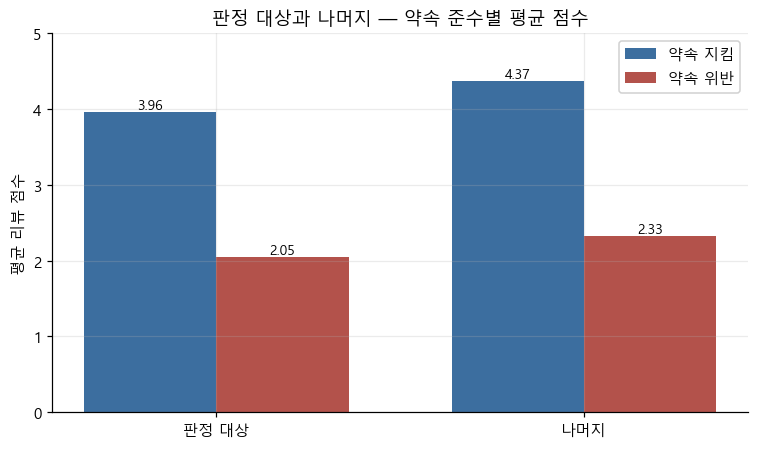

In [14]:
d = con.execute("""
WITH g AS (
    SELECT s.review_score, s.days_vs_promise,
           CASE WHEN m.flagged THEN '1. 판정 대상' ELSE '2. 나머지' END AS grp
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
)
SELECT grp,
       AVG(review_score) FILTER (days_vs_promise <= 0) AS kept,
       AVG(review_score) FILTER (days_vs_promise >  0) AS late
FROM g GROUP BY grp ORDER BY grp
""").df()

x, w = range(len(d)), 0.36
fig, ax = plt.subplots(figsize=(7, 4.2))
b1 = ax.bar([i - w/2 for i in x], d['kept'], w, color=FAST, label='약속 지킴')
b2 = ax.bar([i + w/2 for i in x], d['late'], w, color=SLOW, label='약속 위반')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.04,
            f'{b.get_height():.2f}', ha='center', fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels([s[3:] for s in d['grp']])
ax.set_ylim(0, 5); ax.set_ylabel('평균 리뷰 점수')
ax.set_title('판정 대상과 나머지 — 약속 준수별 평균 점수')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

판정 대상 94 곳의 주문 13,700 건은 평균 3.773, 나머지 80,602 건은 4.242 다. 격차 0.469.
주문 수로 가중한 값이라 판매자별 평균을 그대로 평균한 3.068 과 다르다.

약속 위반율은 판정 대상 9.58 %, 나머지 6.27 % 로 1.53 배다. 더 자주 늦는 것은 맞다.
그런데 약속을 지킨 주문만 보면 3.955 대 4.369 로 0.414 가 남고, 위반한 주문만 보아도
2.050 대 2.329 로 낮다. 네 칸 어디에서도 낮으므로 격차가 위반 비중만으로 설명되지 않는다.

In [15]:
con.execute("""
WITH g AS (
    SELECT s.review_score,
           CASE WHEN m.flagged THEN 'F' ELSE 'R' END AS grp,
           CASE WHEN s.days_vs_promise > 0 THEN '2. 약속 위반' ELSE '1. 약속 지킴' END AS cond
    FROM seller_review AS s JOIN seller_metric AS m USING (seller_id)
),
cel AS (SELECT grp, cond, COUNT(*) AS n, AVG(review_score) AS m FROM g GROUP BY grp, cond),
sh  AS (SELECT grp, cond, m, 1.0 * n / SUM(n) OVER (PARTITION BY grp) AS share FROM cel),
j   AS (SELECT f.cond, f.share AS sf, f.m AS mf, r.share AS sr, r.m AS mr
        FROM (SELECT * FROM sh WHERE grp = 'F') AS f
        JOIN (SELECT * FROM sh WHERE grp = 'R') AS r USING (cond))
SELECT '1. 판정 대상과 나머지의 평균 격차' AS item,
       ROUND(SUM(sf*mf) - SUM(sr*mr), 4)   AS value,
       CAST(100.0 AS DOUBLE)               AS pct
FROM j
UNION ALL
SELECT '2. 약속 위반 비중 차이의 몫', ROUND(SUM((sf-sr)*mr), 4),
       ROUND(100.0 * SUM((sf-sr)*mr) / (SUM(sf*mf) - SUM(sr*mr)), 1) FROM j
UNION ALL
SELECT '3. 같은 조건 안 점수 차이의 몫', ROUND(SUM(sf*(mf-mr)), 4),
       ROUND(100.0 * SUM(sf*(mf-mr)) / (SUM(sf*mf) - SUM(sr*mr)), 1) FROM j
ORDER BY item
""").df()

,item,value,pct
0,1. 판정 대상과 나머지의 평균 격차,-0.4687,100.0
1,2. 약속 위반 비중 차이의 몫,-0.0676,14.4
2,3. 같은 조건 안 점수 차이의 몫,-0.4011,85.6


격차 0.469 중 위반 비중 차이가 만든 몫은 0.068 로 14.4 %,
같은 조건 안에서 벌어진 몫이 0.401 로 85.6 % 다.

판정 대상을 나머지와 같은 위반율로 되돌려도 격차의 다섯 중 넷 이상이 남는다.
예상 도착일을 미루는 처방이 겨냥하는 것은 14.4 % 다.

분해가 낸 85.6 % 가 판정 대상을 고른 규칙과 얼마나 떨어져 있는지 확인한다.

조건 1 은 평균이 낮은 판매자를 고르는 규칙이므로 걸린 판매자의 평균이 낮은 것은 규칙이 정한 것이고,
남는 질문은 그 낮은 평균이 위반을 자주 겪어서 생길 수 있었는가다.
판정 대상이 약속 준수별로 나머지와 똑같은 점수를 받는다고 두고,
위반율이 얼마여야 평균이 그만큼 내려가는지 역산한다.

In [16]:
con.execute("""
WITH cel AS (
    SELECT AVG(s.review_score) FILTER (s.days_vs_promise <= 0) AS m_kept,
           AVG(s.review_score) FILTER (s.days_vs_promise >  0) AS m_late
    FROM seller_review AS s
    JOIN seller_metric AS m USING (seller_id)
    WHERE NOT m.flagged
),
tgt AS (
    SELECT (SELECT AVG(review_score) FROM seller_review)  AS avg_all,
           AVG(s.review_score)                            AS avg_flagged,
           1.0 * COUNT(*) FILTER (s.days_vs_promise > 0)
               / COUNT(*)                                 AS late_flagged
    FROM seller_review AS s
    JOIN seller_metric AS m USING (seller_id)
    WHERE m.flagged
)
SELECT '1. 전체 평균까지 내려가는 데 필요한 위반율'         AS item,
       ROUND(100.0 * (c.m_kept - t.avg_all)
                   / (c.m_kept - c.m_late), 2)              AS late_pct,
       ROUND(t.avg_all, 3)                                  AS avg_at_rate
FROM cel AS c CROSS JOIN tgt AS t

UNION ALL
SELECT '2. 판정 대상의 평균까지 내려가는 데 필요한 위반율',
       ROUND(100.0 * (c.m_kept - t.avg_flagged)
                   / (c.m_kept - c.m_late), 2),
       ROUND(t.avg_flagged, 3)
FROM cel AS c CROSS JOIN tgt AS t

UNION ALL
SELECT '3. 판정 대상의 실제 위반율',
       ROUND(100.0 * t.late_flagged, 2),
       ROUND(c.m_kept - t.late_flagged * (c.m_kept - c.m_late), 3)
FROM cel AS c CROSS JOIN tgt AS t

ORDER BY item
""").df()

,item,late_pct,avg_at_rate
0,1. 전체 평균까지 내려가는 데 필요한 위반율,9.61,4.173
1,2. 판정 대상의 평균까지 내려가는 데 필요한 위반율,29.24,3.773
2,3. 판정 대상의 실제 위반율,9.58,4.174


나머지와 같은 점수를 받으면서 전체 평균 4.174 아래로 내려가려면 위반율이 9.61 % 를 넘어야 한다.
판정 대상의 실제 위반율은 9.58 % 로 그 문턱에 걸쳐 있고, 그 위반율에서 기대되는 평균은 4.174 로
전체 평균과 같다. 실제 평균은 3.773 이다.

**조건 1 이 고른 것은 위반이 잦은 판매자가 아니라 약속 위반 여부와 관계없이 낮은 판매자다.**
위반은 판정 대상 주문의 9.58 % 뿐이라 나머지 90.42 % 인 약속을 지킨 주문에서 낮지 않고는 평균이 문턱 아래로
내려가지 않는다. 위반만으로 실제 평균 3.773 에 닿으려면 위반율이 29.24 % 여야 한다.
약속을 어긴 주문끼리 비교해도 판정 대상은 2.050 으로 나머지의 2.329 보다 낮다.
같은 조건 안 차이가 85.6 % 로 나오는 것은 이 선별 규칙에서 상당 부분 따라 나온다.

분해가 더하는 것은 격차의 방향이 아니라 크기다. 위반율을 나머지와 같게 되돌려도 0.401 이 남는다.

In [17]:
con.execute("""
CREATE OR REPLACE VIEW seller_verdict AS
WITH base AS (
    SELECT AVG(review_score) AS avg_kept_all
    FROM seller_review
    WHERE days_vs_promise <= 0
),
ps AS (
    SELECT seller_id,
           COUNT(*)          FILTER (days_vs_promise <= 0) AS n_kept,
           AVG(review_score) FILTER (days_vs_promise <= 0) AS m_kept,
           STDDEV_SAMP(review_score)
                             FILTER (days_vs_promise <= 0) AS sd_kept,
           COUNT(*)          FILTER (days_vs_promise >  0) AS n_late,
           AVG(review_score) FILTER (days_vs_promise >  0) AS m_late
    FROM seller_review
    GROUP BY seller_id
),
j AS (
    SELECT m.*,
           p.n_kept, p.m_kept, p.sd_kept, p.n_late, p.m_late,
           p.m_kept + 1.96 * p.sd_kept / SQRT(p.n_kept) AS ci_high_kept,
           b.avg_kept_all
    FROM seller_metric AS m
    JOIN ps            AS p USING (seller_id)
    CROSS JOIN base    AS b
)
SELECT *,
       CASE WHEN NOT flagged                       THEN NULL
            WHEN n_kept = 0                        THEN '4. 약속 지킨 주문 없음'
            WHEN ci_high_kept < avg_kept_all       THEN '1. 약속을 지켜도 낮음'
            WHEN m_kept       < avg_kept_all       THEN '2. 낮은 쪽이나 구간이 걸침'
            ELSE                                        '3. 약속을 지키면 낮지 않음' END AS verdict
FROM j
""")

con.execute("""
SELECT verdict,
       COUNT(*)                                         AS sellers,
       CAST(SUM(orders) AS BIGINT)                      AS orders,
       ROUND(AVG(avg_score), 3)                         AS avg_all_orders,
       ROUND(AVG(m_kept), 3)                            AS avg_kept_orders,
       ROUND(100.0 * AVG(late_rate), 2)                 AS late_pct,
       COUNT(*) FILTER (sd_kept IS NULL OR sd_kept = 0) AS no_spread,
       ROUND(MIN(avg_kept_all), 3)                      AS base_kept
FROM seller_verdict
WHERE flagged
GROUP BY verdict
ORDER BY verdict
""").df()

,verdict,sellers,orders,avg_all_orders,avg_kept_orders,late_pct,no_spread,base_kept
0,1. 약속을 지켜도 낮음,62,12049,3.219,3.374,10.58,0,4.311
1,2. 낮은 쪽이나 구간이 걸침,28,1215,2.766,3.204,31.46,5,4.311
2,3. 약속을 지키면 낮지 않음,3,434,3.280,4.373,37.31,0,4.311
3,4. 약속 지킨 주문 없음,1,2,1.500,NaN,100.00,1,4.311


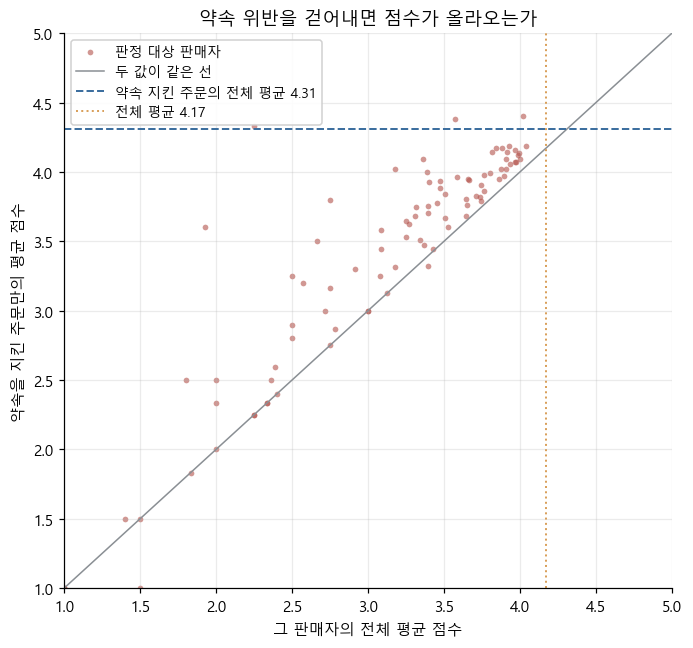

In [18]:
d = con.execute("""
SELECT seller_id, avg_score, m_kept
FROM seller_verdict
WHERE flagged AND m_kept IS NOT NULL
""").df()

base_all  = con.execute("SELECT AVG(review_score) FROM seller_review").fetchone()[0]
base_kept = con.execute("SELECT MIN(avg_kept_all) FROM seller_verdict").fetchone()[0]

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(d['avg_score'], d['m_kept'], s=14, c=SLOW, alpha=0.6, linewidths=0,
           label='판정 대상 판매자')
ax.plot([1, 5], [1, 5], color='#8A8F94', lw=1.0, label='두 값이 같은 선')
ax.axhline(base_kept, color=FAST, lw=1.3, ls='--',
           label=f'약속 지킨 주문의 전체 평균 {base_kept:.2f}')
ax.axvline(base_all, color=MID, lw=1.3, ls=':', label=f'전체 평균 {base_all:.2f}')
ax.set_xlim(1, 5); ax.set_ylim(1, 5)
ax.set_xlabel('그 판매자의 전체 평균 점수')
ax.set_ylabel('약속을 지킨 주문만의 평균 점수')
ax.set_title('약속 위반을 걷어내면 점수가 올라오는가')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

판매자마다 다시 판정하면 94 곳이 넷으로 나뉜다. 기준은 약속을 지킨 주문의 전체 평균 4.311.

- **약속을 지켜도 낮음 62 곳, 주문 12,049 건.** 3.219 가 약속 지킨 주문만 보아도 3.374 로
  0.155 만 오른다. 4.311 과는 여전히 멀고 위반율도 10.58 % 로 판정 대상 평균 언저리다
- **낮은 쪽이나 구간이 걸침 28 곳, 주문 1,215 건.** 2.766 에서 3.204 로 오르지만 4.311 에 못 미친다.
  판매자당 주문이 43 건이라 구간이 넓어 단정하지 못하는 쪽이지 평균으로 올라온 쪽이 아니다
- **약속을 지키면 낮지 않음 3 곳, 주문 434 건.** 3.280 이 4.373 으로 올라 기준을 넘는다.
  위반율 37.31 % 로 판정 대상 평균의 네 배다
- **약속 지킨 주문 없음 1 곳, 주문 2 건**

산점도에서 점 대부분이 같은 값 선에서 조금 위에 있다. 위반을 걷어내도 점수가 거의 그대로라는 뜻이다.
오른쪽 위로 크게 올라간 점 셋이 세 번째 무리다.
약속을 지킨 주문이 없는 1 곳은 세로축 값이 없어 빠졌으므로 그림의 점은 93 개다.

**조건 2 — 두 쪽이 섞였고 한쪽이 압도적이다.** 배송 밖 요인이 62 곳(주문 12,049 건,
판정 대상 주문의 88.0 %), 배송이 전부인 쪽이 3 곳(434 건, 3.2 %).

## 6. 약속 위반을 더 자주 일으키는 판매자가 있는가

5 에서 판정 대상의 위반율은 9.58 % 로 나머지 6.27 % 보다 높았다. 다만 판정 대상은 고객 만족도로 고른 판매자라,
위반을 자주 일으키는 판매자가 따로 있는지는 위반을 기준으로 다시 골라야 알 수 있다.
판매자에 따라 예상 도착일을 달리 미루는 방법은 위반이 일부 판매자에게 몰려 있을 때 의미가 있다.

고르는 방식은 4 와 같다. 판매자별 약속 위반율의 Wilson 95 % 구간 하한이 전체 위반율보다 높은 판매자를 고르고,
결과를 뷰 `seller_late` 로 고정한다. 약속 위반은 `days_vs_promise > 0` 인 주문.

- `late_n` · `late_rate` — 그 판매자의 위반 수와 위반율
- `wilson_low_late` — 위반율의 Wilson 95 % 구간 하한
- `hit_late` — `wilson_low_late` 가 전체 위반율 `late_all` 보다 높음

In [19]:
con.execute("""
CREATE OR REPLACE VIEW seller_late AS
WITH base AS (
    SELECT AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_all
    FROM seller_review
),
per_seller AS (
    SELECT seller_id,
           COUNT(*)                              AS orders,
           COUNT(*) FILTER (days_vs_promise > 0) AS late_n
    FROM seller_review
    GROUP BY seller_id
),
calc AS (
    SELECT p.seller_id,
           p.orders,
           p.late_n,
           1.0 * p.late_n / p.orders                  AS late_rate,
           ((1.0 * p.late_n / p.orders + 1.9208 / p.orders)
            - 1.96 * SQRT((1.0 * p.late_n / p.orders)
                          * (1 - 1.0 * p.late_n / p.orders) / p.orders
                          + 0.9604 / (p.orders * p.orders)))
           / (1 + 3.8416 / p.orders)                  AS wilson_low_late,
           b.late_all
    FROM per_seller AS p
    CROSS JOIN base AS b
)
SELECT seller_id, orders, late_n, late_rate, wilson_low_late, late_all,
       wilson_low_late > late_all AS hit_late
FROM calc
""")

con.execute("""
SELECT COUNT(*)                       AS sellers,
       CAST(SUM(orders) AS BIGINT)    AS orders,
       CAST(SUM(late_n) AS BIGINT)    AS late_orders,
       ROUND(MIN(late_all), 4)        AS late_all,
       COUNT(*) FILTER (late_n = 0)   AS no_late_sellers
FROM seller_late
""").df()

,sellers,orders,late_orders,late_all,no_late_sellers
0,2922,94302,6366,0.0675,1669


규모별로 나눠 실제로 걸린 판매자 수와 우연으로 걸리는 수의 기대치를 비교한다.
기대치는 4 와 같은 방식으로, 판매자가 주문마다 위반을 겪을 확률이 전체 위반율과 같다고 두고 이항분포로 구한다.

- `hit_late` — 위반율의 Wilson 하한이 전체 위반율보다 높은 판매자 수
- `chance_max` — 판매자 수 × 2.5 %
- `chance_exact` — 이항분포로 구한 우연 기대치
- `ratio` — `hit_late` ÷ `chance_exact`
- `hit_orders` · `hit_late_orders` · `hit_late_pct` — 걸린 판매자의 주문 수, 위반 수, 위반율

In [20]:
con.execute("""
WITH base AS (
    SELECT MIN(late_all) AS p
    FROM seller_late
),
sizes AS (
    SELECT DISTINCT orders AS n
    FROM seller_late
),
grid AS (
    SELECT n, UNNEST(generate_series(0, n)) AS k
    FROM sizes
),
prob AS (
    SELECT g.n,
           g.k,
           EXP(LGAMMA(g.n + 1) - LGAMMA(g.k + 1) - LGAMMA(g.n - g.k + 1)
               + g.k * LN(b.p) + (g.n - g.k) * LN(1 - b.p))          AS pmf,
           ((1.0 * g.k / g.n + 1.9208 / g.n)
            - 1.96 * SQRT((1.0 * g.k / g.n) * (1 - 1.0 * g.k / g.n) / g.n
                          + 0.9604 / (g.n * g.n)))
           / (1 + 3.8416 / g.n) > b.p                                  AS hit
    FROM grid AS g
    CROSS JOIN base AS b
),
per_n AS (
    SELECT n,
           COALESCE(SUM(pmf) FILTER (hit), 0) AS p_hit
    FROM prob
    GROUP BY n
),
per_seller AS (
    SELECT CASE WHEN s.orders >= 100 THEN '1. 100건 이상'
                WHEN s.orders >=  50 THEN '2. 50~99건'
                WHEN s.orders >=  20 THEN '3. 20~49건'
                WHEN s.orders >=  10 THEN '4. 10~19건'
                WHEN s.orders >=   5 THEN '5. 5~9건'
                ELSE                      '6. 5건 미만' END AS bucket,
           s.orders,
           s.late_n,
           s.hit_late,
           p.p_hit
    FROM seller_late AS s
    JOIN per_n       AS p ON p.n = s.orders
)
SELECT COALESCE(bucket, '0. 전체')                                AS bucket,
       COUNT(*)                                                   AS sellers,
       COUNT(*) FILTER (hit_late)                                 AS hit_late,
       ROUND(0.025 * COUNT(*), 1)                                 AS chance_max,
       ROUND(SUM(p_hit), 1)                                       AS chance_exact,
       ROUND(COUNT(*) FILTER (hit_late) / SUM(p_hit), 2)          AS ratio,
       CAST(SUM(orders) FILTER (hit_late) AS BIGINT)              AS hit_orders,
       CAST(SUM(late_n) FILTER (hit_late) AS BIGINT)              AS hit_late_orders,
       ROUND(100.0 * SUM(late_n) FILTER (hit_late)
                   / SUM(orders) FILTER (hit_late), 2)            AS hit_late_pct
FROM per_seller
GROUP BY GROUPING SETS ((bucket), ())
ORDER BY bucket
""").df()

,bucket,sellers,hit_late,chance_max,chance_exact,ratio,hit_orders,hit_late_orders,hit_late_pct
0,0. 전체,2922,241,73.1,154.7,1.56,17243,2274,13.19
1,1. 100건 이상,200,35,5.0,6.3,5.54,13823,1492,10.79
2,2. 50~99건,208,22,5.2,7.3,3.00,1661,273,16.44
3,3. 20~49건,376,27,9.4,14.8,1.83,956,200,20.92
4,4. 10~19건,426,27,10.7,16.7,1.62,382,108,28.27
5,5. 5~9건,520,38,13.0,29.4,1.29,269,93,34.57
6,6. 5건 미만,1192,92,29.8,80.2,1.15,152,108,71.05


전체 위반율은 6.75 %(위반 6,366 건). 위반율의 Wilson 하한이 이보다 높은 판매자는 241 곳이고,
우연으로 걸리는 수의 기대치는 154.7 곳으로 판매자 수에 2.5 % 를 곱한 73.1 곳의 두 배가 넘는다.
전체 위반율이 낮아 주문이 적은 판매자는 위반 한두 건으로도 기준을 넘기 때문이다.
주문 두 건 중 한 건만 늦어도 하한이 0.095 라, 위반율이 전체와 같은 판매자도 13.0 % 확률로 걸린다.

**위반이 잦은 판매자가 실재하고, 근거는 주문이 많은 쪽에 있다.** 100 건 이상에서 35 곳이 걸려
기대치 6.3 곳의 5.54 배, 50 ~ 99 건에서 22 곳으로 3.00 배다. 20 ~ 49 건 1.83 배, 10 ~ 19 건 1.62 배로 내려가고,
5 ~ 9 건 1.29 배, 5 건 미만 1.15 배에서는 걸린 수 대부분이 우연 기대치로 설명된다.

걸린 241 곳은 주문 17,243 건(표본의 18.28 %)에서 위반 2,274 건(전체 위반의 35.72 %)을 내며 위반율은 13.19 % 다.
그 주문의 80.2 % 인 13,823 건이 100 건 이상 판매자에게서 나온다.

위반이 잦은 판매자와 조건 1 의 판정 대상이 얼마나 겹치는지, 네 무리가 주문과 위반에서 각각 얼마를 차지하는지 센다.

- `pct_orders` · `pct_late` — 표본 전체 주문과 전체 위반에서 그 무리가 차지하는 비율
- `late_pct` — 그 무리 안의 위반율
- `avg_score` — 그 무리 주문의 평균 리뷰 점수

In [21]:
con.execute("""
SELECT CASE WHEN l.hit_late AND m.flagged THEN '1. 위반 잦음 · 판정 대상'
            WHEN l.hit_late               THEN '2. 위반 잦음'
            WHEN m.flagged                THEN '3. 판정 대상'
            ELSE                               '4. 둘 다 아님' END           AS grp,
       COUNT(*)                                                      AS sellers,
       CAST(SUM(l.orders) AS BIGINT)                                 AS orders,
       ROUND(100.0 * SUM(l.orders) / SUM(SUM(l.orders)) OVER (), 2)  AS pct_orders,
       CAST(SUM(l.late_n) AS BIGINT)                                 AS late_orders,
       ROUND(100.0 * SUM(l.late_n) / SUM(SUM(l.late_n)) OVER (), 2)  AS pct_late,
       ROUND(100.0 * SUM(l.late_n) / SUM(l.orders), 2)               AS late_pct,
       ROUND(SUM(m.avg_score * m.orders) / SUM(m.orders), 3)         AS avg_score
FROM seller_late   AS l
JOIN seller_metric AS m USING (seller_id)
GROUP BY grp
ORDER BY grp
""").df()

,grp,sellers,orders,pct_orders,late_orders,pct_late,late_pct,avg_score
0,1. 위반 잦음 · 판정 대상,45,5549,5.88,768,12.06,13.84,3.635
1,2. 위반 잦음,196,11694,12.40,1506,23.66,12.88,4.102
2,3. 판정 대상,49,8151,8.64,545,8.56,6.69,3.867
3,4. 둘 다 아님,2632,68908,73.07,3547,55.72,5.15,4.265


조건 1 의 판정 대상 94 곳 중 45 곳은 위반도 잦고 49 곳은 그렇지 않다.

- **위반 잦음 · 판정 대상 45 곳** — 주문 5,549 건(5.88 %), 위반율 13.84 %, 평균 3.635
- **위반 잦음 196 곳** — 주문 11,694 건(12.40 %), 위반율 12.88 %, 평균 4.102
- **판정 대상 49 곳** — 주문 8,151 건(8.64 %), 위반율 6.69 %, 평균 3.867
- **둘 다 아님 2,632 곳** — 주문 68,908 건(73.07 %), 위반율 5.15 %, 평균 4.265

위반만 잦은 196 곳은 위반율이 45 곳과 비슷한데 평균이 4.102 로 판정 대상에 들지 않았다.
판정 대상이면서 위반이 잦지 않은 49 곳은 위반율 6.69 % 가 전체 6.75 % 와 같은 수준인데 평균이 3.867 이다.
판매자 단위에서도 위반이 잦은 것과 고객 만족도가 낮은 것은 상당 부분 따로 나타난다.

위반이 잦은 판매자에게 예상 도착일을 더 미룰 때와 모든 주문에 미룰 때를 06 과 같은 방식으로 비교한다.

패딩의 이득은 둘이다. 위반이 약속 준수로 바뀌는 것과, 여전히 늦는 주문의 지연 일수가 줄어드는 것.
주문마다 지연 일수에서 패딩 일수를 빼고, 절대 소요일 구간을 고정한 채 바뀐 약속 준수 상태
(일찍 · 당일 · 1 ~ 4 일 늦음 · 5 일 이상 늦음)의 관측 평균 점수와 1 점 비율로 바꿔 다시 계산한다.
칸의 관측값은 이 노트북의 표본 전체에서 구한다. 관측된 지연과 만족도의 관계가 약속을 바꾼 뒤에도 유지된다는 가정은 06 과 같다.

비교의 축도 06 과 같다. 평균 며칠을 미뤘는가와 1 점 주문이 몇 건 줄었는가.

- `avg_pad_days` — 표본 주문당 평균 미룬 일수
- `late_pct` · `removed` — 패딩 뒤 위반율과 약속 준수로 바뀐 위반 수
- `expected_score` · `expected_1_orders` — 패딩 뒤 기대 평균 점수와 기대 1 점 주문 수
- `cut_1_orders` — 패딩 없음 대비 1 점 주문 감소
- `cut_per_day` — `cut_1_orders` ÷ `avg_pad_days`. 06 의 미룬 하루당 감소와 같은 값

In [22]:
con.execute("""
WITH base AS (
    SELECT CASE WHEN s.delivery_days <=  7 THEN '1. 0~7일'
                WHEN s.delivery_days <= 14 THEN '2. 8~14일'
                WHEN s.delivery_days <= 21 THEN '3. 15~21일'
                WHEN s.delivery_days <= 30 THEN '4. 22~30일'
                ELSE                            '5. 31일 이상' END AS days_bucket,
           s.days_vs_promise,
           s.review_score,
           l.hit_late
    FROM seller_review AS s
    JOIN seller_late   AS l USING (seller_id)
),
cell_stat AS (
    SELECT days_bucket,
           CASE WHEN days_vs_promise <  0 THEN 'early'
                WHEN days_vs_promise =  0 THEN 'ontime'
                WHEN days_vs_promise <= 4 THEN 'late1'
                ELSE                          'late5' END AS promise_status,
           AVG(review_score)                                     AS mean_score,
           AVG(CASE WHEN review_score = 1 THEN 1.0 ELSE 0.0 END) AS rate_1
    FROM base
    GROUP BY days_bucket, promise_status
),
policy AS (
    SELECT * FROM (VALUES
        ('1. 패딩 없음',                         0, 0),
        ('2. 일괄 3일',                          3, 3),
        ('3. 일괄 5일',                          5, 5),
        ('4. 일괄 7일',                          7, 7),
        ('5. 위반 잦은 판매자 3일',              3, 0),
        ('6. 위반 잦은 판매자 5일',              5, 0),
        ('7. 위반 잦은 판매자 7일',              7, 0),
        ('8. 위반 잦은 판매자 7일 · 나머지 3일', 7, 3)
    ) AS t(policy, pad_late, pad_rest)
),
shifted AS (
    SELECT p.policy,
           CASE WHEN b.hit_late THEN p.pad_late ELSE p.pad_rest END AS pad,
           b.days_bucket,
           b.days_vs_promise,
           b.days_vs_promise
             - CASE WHEN b.hit_late THEN p.pad_late ELSE p.pad_rest END AS new_late
    FROM base AS b
    CROSS JOIN policy AS p
),
staged AS (
    SELECT *,
           CASE WHEN new_late <  0 THEN 'early'
                WHEN new_late =  0 THEN 'ontime'
                WHEN new_late <= 4 THEN 'late1'
                ELSE                    'late5' END AS new_status
    FROM shifted
),
agg AS (
    SELECT s.policy,
           ROUND(AVG(s.pad), 2)                                          AS avg_pad_days,
           ROUND(100.0 * COUNT(*) FILTER (s.new_late > 0) / COUNT(*), 2) AS late_pct,
           COUNT(*) FILTER (s.days_vs_promise > 0 AND s.new_late <= 0)  AS removed,
           ROUND(AVG(c.mean_score), 3)                                   AS expected_score,
           ROUND(AVG(c.rate_1) * COUNT(*))                               AS expected_1_orders
    FROM staged    AS s
    JOIN cell_stat AS c ON s.days_bucket = c.days_bucket
                       AND s.new_status  = c.promise_status
    GROUP BY s.policy
)
SELECT policy,
       avg_pad_days,
       late_pct,
       removed,
       expected_score,
       expected_1_orders,
       first_value(expected_1_orders) OVER (ORDER BY policy) - expected_1_orders AS cut_1_orders,
       ROUND((first_value(expected_1_orders) OVER (ORDER BY policy) - expected_1_orders)
             / NULLIF(avg_pad_days, 0))                                          AS cut_per_day
FROM agg
ORDER BY policy
""").df()

,policy,avg_pad_days,late_pct,removed,expected_score,expected_1_orders,cut_1_orders,cut_per_day
0,1. 패딩 없음,0.00,6.75,0,4.173,8866.0,0.0,NaN
1,2. 일괄 3일,3.00,4.79,1845,4.207,8091.0,775.0,258.0
2,3. 일괄 5일,5.00,3.88,2711,4.221,7741.0,1125.0,225.0
3,4. 일괄 7일,7.00,2.95,3587,4.233,7435.0,1431.0,204.0
4,5. 위반 잦은 판매자 3일,0.55,6.13,588,4.185,8598.0,268.0,487.0
5,6. 위반 잦은 판매자 5일,0.91,5.82,875,4.190,8473.0,393.0,432.0
6,7. 위반 잦은 판매자 7일,1.28,5.47,1212,4.195,8353.0,513.0,401.0
7,8. 위반 잦은 판매자 7일 · 나머지 3일,3.73,4.13,2469,4.216,7846.0,1020.0,273.0


**1 점 주문 감소로 재도 판매자로 겨냥하면 미룬 하루당 이득이 크다.** 미룬 하루당 1 점 주문 감소가
일괄 3 · 5 · 7 일에 258 · 225 · 204 건, 위반이 잦은 판매자에게만 3 · 5 · 7 일을 미루면 487 · 432 · 401 건이다.
이 감소에는 위반이 약속 준수로 바뀐 주문과 여전히 늦되 덜 늦어진 주문이 함께 들어 있다.

**일괄 3 일과 위반이 잦은 판매자에게만 7 일을 견주면 미룬 날짜의 차이가 크다.** 일괄 3 일은 주문 94,302 건 모두에
3 일씩 미뤄 주문당 평균 3.00 일이고, 판매자 7 일은 주문의 18.28 % 인 17,243 건에만 7 일씩 미뤄 주문당 평균 1.28 일이다.
미룬 날짜는 42.7 % 인데 1 점 주문 감소는 513 건으로 일괄 3 일의 775 건 중 66.2 % 에 이른다.

**둘을 섞으면 추가분의 효율이 높다.** 모든 주문에 3 일을 미루고 위반이 잦은 판매자에게는 7 일을 미루면
평균 3.73 일에 1 점 주문이 1,020 건 준다. 일괄 3 일보다 평균 0.73 일을 더 미뤄 245 건을 더 줄이므로 추가 하루당 336 건이다.
일괄 3 일을 5 일로 늘리면 2 일을 더 미뤄 350 건을 더 줄여 추가 하루당 175 건이다.
일괄 7 일(평균 7 일, 1,431 건)과 견주면 그 71.3 % 를 53.3 % 의 날짜로 얻는다.

차이는 위반이 몰려 있어서 생긴다. 위반이 잦은 판매자는 주문의 18.28 % 에서 위반의 35.72 % 를 내고,
지연의 깊이는 전체와 비슷하다. 그 판매자들의 위반 2,274 건 중 3 일로 약속 준수가 되는 것은 25.9 %,
5 일 38.5 %, 7 일 53.3 % 로 전체의 28.98 %, 42.59 %, 56.35 % 와 비슷하거나 조금 낮다.

**위반이 잦지 않은 판매자의 주문 77,059 건(81.72 %)은 예상 도착일이 그대로다.** 약속을 지키는 판매자의 고객이
다른 판매자의 위반 때문에 늦춰진 예상 도착일을 받지 않는다.

일괄 3 일의 1 점 주문 감소 775 건과 미룬 하루당 258 건은 06 의 773 건 · 258 건과 거의 같다.
표본이 판매자 한 곳인 주문으로 좁혀져도 두 노트북의 수치를 같은 축에 놓을 수 있다.

**06 의 시기별 차등과 다른 점과 같은 점.**

06 에서 시기별로 달리 미루는 정책은 급증을 완벽하게 알아맞혔을 때의 상한으로 남았다.
예상 도착일은 주문 시점에 제시되는데, 그 달이 급증 달인지는 20 개월을 다 본 뒤에야 알 수 있었다.

**다른 점 — 누가 파는지는 주문 시점에 정해져 있다.**
그 판매자가 그전에 완료한 주문의 위반율도 이미 쌓여 있다. 차등의 기준이 주문 시점에 존재하므로,
시기별 차등을 막은 문제가 판매자 축에는 없다.

**같은 점 — 여기 241 곳도 20 개월 전체를 보고 골랐다.** 운영 시점에는 그때까지의 이력만 쓸 수 있으므로,
위 표의 판매자별 수치도 06 과 같이 위반이 잦은 판매자를 완벽하게 알아맞혔을 때의 상한이다.
06 과 갈리는 것은 알아맞힐 기준이 주문 시점에 존재하느냐다.
과거 이력만으로 같은 판매자 집합이 잡히는지는 7 에서 확인한다.

주문 100 건 이상에서 걸린 판매자는 우연 기대치의 5.54 배라 우연으로 모인 집합은 아니다.
다만 우연이 아니라는 것과 이전 기간의 이력으로 미리 잡힌다는 것은 다른 문제다.

## 7. 이전 12 개월의 이력으로 고른 판매자는 이후에도 위반이 잦은가

6 의 241 곳은 20 개월 전체의 위반으로 골랐다. 판매자별로 예상 도착일을 달리 미루려면 주문 시점까지 쌓인 이력만으로
판매자를 골라야 하므로, 앞 기간의 이력으로 고른 판매자가 뒤 기간에도 위반이 잦은지 확인.

기간은 2018-01-01 을 기준 시점으로 나눈다.

- **이전** — 2017-01 ~ 2017-12 에 구매하고 2017 년 안에 수령한 주문. 기준 시점에 위반 여부가 확정된 주문만 이력으로 쓴다
- **이후** — 2018-01 ~ 2018-08 에 구매한 주문
- **제외** — 2017 년에 구매해 2018 년에 수령한 주문. 기준 시점에 결과가 없어 이력에 넣을 수 없고, 구매가 기준 시점 전이라 이후에도 넣지 않는다

수령일은 뷰에 없어 구매일의 날짜에 `delivery_days` 를 더해 구한다. `delivery_days` 가 구매일과 수령일의 날짜 차이라 더하면 수령일의 날짜가 된다.

먼저 기간별 규모와 위반율.

- `orders` · `sellers` — 그 기간의 주문 수와 판매자 수
- `late_pct` — 그 기간의 위반율

In [23]:
con.execute("""
SELECT CASE WHEN order_purchase_timestamp >= DATE '2018-01-01'
            THEN '3. 이후 — 2018 년 구매'
            WHEN CAST(order_purchase_timestamp AS DATE)
                 + CAST(delivery_days AS INTEGER) < DATE '2018-01-01'
            THEN '1. 이전 — 2017 년 구매 · 2017 년 수령'
            ELSE '2. 제외 — 2017 년 구매 · 2018 년 수령' END              AS period,
       COUNT(*)                                                         AS orders,
       COUNT(DISTINCT seller_id)                                        AS sellers,
       ROUND(100.0 * AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END), 2) AS late_pct
FROM seller_review
GROUP BY period
ORDER BY period
""").df()

,period,orders,sellers,late_pct
0,1. 이전 — 2017 년 구매 · 2017 년 수령,40180,1648,4.24
1,2. 제외 — 2017 년 구매 · 2018 년 수령,2444,615,27.54
2,3. 이후 — 2018 년 구매,51678,2307,7.72


이전 40,180 건(판매자 1,648 곳), 이후 51,678 건(2,307 곳)이다.
위반율은 이전 4.24 %, 이후 7.72 % 로 이후가 1.8 배다.

제외한 2,444 건은 위반율이 27.54 % 다. 2017 년에 사서 2018 년에 받은 주문이라 구조상 배송이 긴 주문이 모인 집합이다.
기준 시점에 수령되지 않아 운영 시점의 이력에도 들어갈 수 없는 주문이지만, 이 위반들이 빠진 만큼 이전 기간의 기준선 4.24 % 가 낮게 잡혔다.
기준선이 낮으면 판매자의 위반율 Wilson 하한이 기준을 넘기 쉬워, 아래에서 이전 기간에 걸리는 판매자 158 곳이라는 선별 결과도 이 영향을 받는다.

이전 기간의 이력으로 판매자를 고르고, 이후 기간의 주문을 그 판정으로 나눠 위반율을 비교한다.
고르는 방식은 6 과 같다. 이전 기간의 판매자별 위반율 Wilson 하한이 이전 기간 전체 위반율보다 높은 판매자.
두 기간의 위반율이 4.24 % 와 7.72 % 로 달라, 각 기간의 전체 위반율을 그 기간의 기준으로 쓴다.

이후 기간에도 같은 기준을 이후 기간 전체 위반율로 적용해 다시 걸리는 판매자를 센다.
다만 이후 기간은 8 개월이라 판매자당 주문이 적고 구간이 넓어, 위반율이 높은 판매자도 다시 걸리기 어렵다.
그래서 비교의 중심은 다시 걸린 수가 아니라 이후 기간의 위반율이다.

- `sellers` — 이후 기간에 주문이 있는 판매자 수
- `post_orders` · `pct_orders` — 이후 기간 주문 수와 그 비율
- `post_late` · `pct_late` — 이후 기간 위반 수와 전체 위반 중 비율
- `late_pct` — 이후 기간 위반율
- `hit_post` · `hit_post_pct` — 이후 기간에도 기준에 걸린 판매자 수와 비율

In [24]:
con.execute("""
WITH base AS (
    SELECT seller_id,
           days_vs_promise,
           CASE WHEN order_purchase_timestamp >= DATE '2018-01-01'
                THEN 'post'
                WHEN CAST(order_purchase_timestamp AS DATE)
                     + CAST(delivery_days AS INTEGER) < DATE '2018-01-01'
                THEN 'prev'
           END AS period
    FROM seller_review
),
rate AS (
    SELECT period,
           AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_all
    FROM base
    WHERE period IS NOT NULL
    GROUP BY period
),
per_seller AS (
    SELECT b.seller_id,
           b.period,
           COUNT(*)                                AS orders,
           COUNT(*) FILTER (b.days_vs_promise > 0) AS late_n,
           MIN(r.late_all)                         AS late_all
    FROM base AS b
    JOIN rate AS r USING (period)
    GROUP BY b.seller_id, b.period
),
flag AS (
    SELECT seller_id,
           period,
           orders,
           late_n,
           ((1.0 * late_n / orders + 1.9208 / orders)
            - 1.96 * SQRT((1.0 * late_n / orders) * (1 - 1.0 * late_n / orders) / orders
                          + 0.9604 / (orders * orders)))
           / (1 + 3.8416 / orders) > late_all AS hit
    FROM per_seller
),
prev AS (SELECT * FROM flag WHERE period = 'prev'),
post AS (SELECT * FROM flag WHERE period = 'post')
SELECT CASE WHEN pv.seller_id IS NULL THEN '3. 이전 주문 없음'
            WHEN pv.hit               THEN '1. 이전에 위반 잦음'
            ELSE                           '2. 이전에 위반 잦지 않음' END          AS grp,
       COUNT(*)                                                             AS sellers,
       CAST(SUM(ps.orders) AS BIGINT)                                       AS post_orders,
       ROUND(100.0 * SUM(ps.orders) / SUM(SUM(ps.orders)) OVER (), 2)       AS pct_orders,
       CAST(SUM(ps.late_n) AS BIGINT)                                       AS post_late,
       ROUND(100.0 * SUM(ps.late_n) / SUM(SUM(ps.late_n)) OVER (), 2)       AS pct_late,
       ROUND(100.0 * SUM(ps.late_n) / SUM(ps.orders), 2)                    AS late_pct,
       COUNT(*) FILTER (ps.hit)                                             AS hit_post,
       ROUND(100.0 * COUNT(*) FILTER (ps.hit) / COUNT(*), 1)                AS hit_post_pct
FROM post      AS ps
LEFT JOIN prev AS pv USING (seller_id)
GROUP BY grp
ORDER BY grp
""").df()

,grp,sellers,post_orders,pct_orders,post_late,pct_late,late_pct,hit_post,hit_post_pct
0,1. 이전에 위반 잦음,90,5175,10.01,531,13.31,10.26,18,20.0
1,2. 이전에 위반 잦지 않음,952,33256,64.35,2579,64.65,7.75,91,9.6
2,3. 이전 주문 없음,1265,13247,25.63,879,22.04,6.64,78,6.2


**이전 기간의 이력으로 고른 판매자는 이후에도 위반율이 높다.** 이전에 걸린 판매자 중 이후 기간에 주문이 있는 90 곳의
이후 위반율은 10.26 % 로, 이전에 걸리지 않은 952 곳의 7.75 %, 이전 주문이 없는 1,265 곳의 6.64 % 보다 높다.
90 곳은 이후 주문의 10.01 % 에서 위반의 13.31 % 를 낸다. 이후 기간에도 기준에 다시 걸린 비율은 20.0 % 대 9.6 % 다.
이전 주문이 없는 1,265 곳은 이후 기간 판매자 2,307 곳의 절반이 넘으며, 이전 이력이 없어 판정할 수 없다.

**다만 20 개월 전체로 고른 241 곳보다 위반이 덜 몰린다.** 241 곳은 주문의 18.28 % 에서 위반의 35.72 % 를 냈다.
그 수치는 고른 기간과 잰 기간이 같고, 여기서는 이전 기간으로 고르고 이후 기간에서 잰다.

6 에서 위반이 잦은 판매자의 근거는 주문이 많은 쪽에 있었다. 이전 기간의 주문 규모별로 나눠
이전에 걸린 판매자와 걸리지 않은 판매자의 이후 위반율을 나란히 본다.
이전 기간에 주문이 있었으나 이후 기간에 주문이 없는 판매자도 함께 센다.

- `hit_sellers` · `hit_active` — 이전에 걸린 판매자 수와 그중 이후 기간에 주문이 있는 수
- `hit_post_orders` · `hit_late_pct` — 그 판매자들의 이후 기간 주문 수와 위반율
- `rest_sellers` · `rest_active` · `rest_post_orders` · `rest_late_pct` — 이전에 걸리지 않은 판매자의 같은 값

In [25]:
con.execute("""
WITH base AS (
    SELECT seller_id,
           days_vs_promise,
           CASE WHEN order_purchase_timestamp >= DATE '2018-01-01'
                THEN 'post'
                WHEN CAST(order_purchase_timestamp AS DATE)
                     + CAST(delivery_days AS INTEGER) < DATE '2018-01-01'
                THEN 'prev'
           END AS period
    FROM seller_review
),
rate AS (
    SELECT period,
           AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_all
    FROM base
    WHERE period IS NOT NULL
    GROUP BY period
),
per_seller AS (
    SELECT b.seller_id,
           b.period,
           COUNT(*)                                AS orders,
           COUNT(*) FILTER (b.days_vs_promise > 0) AS late_n,
           MIN(r.late_all)                         AS late_all
    FROM base AS b
    JOIN rate AS r USING (period)
    GROUP BY b.seller_id, b.period
),
flag AS (
    SELECT seller_id,
           period,
           orders,
           late_n,
           ((1.0 * late_n / orders + 1.9208 / orders)
            - 1.96 * SQRT((1.0 * late_n / orders) * (1 - 1.0 * late_n / orders) / orders
                          + 0.9604 / (orders * orders)))
           / (1 + 3.8416 / orders) > late_all AS hit
    FROM per_seller
),
prev AS (SELECT * FROM flag WHERE period = 'prev'),
post AS (SELECT * FROM flag WHERE period = 'post'),
joined AS (
    SELECT CASE WHEN pv.orders >= 100 THEN '1. 100건 이상'
                WHEN pv.orders >=  50 THEN '2. 50~99건'
                WHEN pv.orders >=  20 THEN '3. 20~49건'
                WHEN pv.orders >=  10 THEN '4. 10~19건'
                WHEN pv.orders >=   5 THEN '5. 5~9건'
                ELSE                       '6. 5건 미만' END AS bucket,
           pv.hit,
           ps.orders AS post_orders,
           ps.late_n AS post_late
    FROM prev      AS pv
    LEFT JOIN post AS ps USING (seller_id)
)
SELECT COALESCE(bucket, '0. 전체')                                            AS bucket,
       COUNT(*) FILTER (hit)                                                 AS hit_sellers,
       COUNT(post_orders) FILTER (hit)                                       AS hit_active,
       CAST(SUM(post_orders) FILTER (hit) AS BIGINT)                         AS hit_post_orders,
       ROUND(100.0 * SUM(post_late) FILTER (hit)
                   / SUM(post_orders) FILTER (hit), 2)                       AS hit_late_pct,
       COUNT(*) FILTER (NOT hit)                                             AS rest_sellers,
       COUNT(post_orders) FILTER (NOT hit)                                   AS rest_active,
       CAST(SUM(post_orders) FILTER (NOT hit) AS BIGINT)                     AS rest_post_orders,
       ROUND(100.0 * SUM(post_late) FILTER (NOT hit)
                   / SUM(post_orders) FILTER (NOT hit), 2)                   AS rest_late_pct
FROM joined
GROUP BY GROUPING SETS ((bucket), ())
ORDER BY bucket
""").df()

,bucket,hit_sellers,hit_active,hit_post_orders,hit_late_pct,rest_sellers,rest_active,rest_post_orders,rest_late_pct
0,0. 전체,158,90,5175,10.26,1490,952,33256,7.75
1,1. 100건 이상,7,7,3325,9.29,79,75,13270,7.84
2,2. 50~99건,12,12,663,13.57,87,80,3993,7.54
3,3. 20~49건,12,11,222,9.91,197,166,5804,8.10
4,4. 10~19건,19,13,283,8.48,209,169,4533,7.30
5,5. 5~9건,18,11,264,16.29,258,160,2223,6.48
6,6. 5건 미만,90,36,418,10.29,660,302,3433,8.53


이전 기간의 주문 규모 구간 모두에서 이전에 걸린 판매자의 이후 위반율이 걸리지 않은 판매자보다 높다.

이전 기간은 12 개월이라 주문 100 건 이상인 판매자가 86 곳으로 6 의 20 개월 200 곳보다 적고, 그중 걸린 곳은 7 곳이다.
그 7 곳의 이후 주문 3,325 건이 이전에 걸린 판매자의 이후 주문 5,175 건 중 64.3 % 를 차지한다.

이전에 걸린 158 곳 중 이후 기간에 주문이 있는 곳은 90 곳이다. 50 건 이상에서 걸린 19 곳은 모두 이후에도 주문이 있고,
5 건 미만에서 걸린 90 곳은 36 곳만 이후에 주문이 있다.

이력으로 고른 판매자에게 예상 도착일을 더 미룰 때의 효과를 6 과 같은 축, 미룬 하루당 1 점 주문 감소로 잰다.

계산 방식과 정책 목록은 6 과 같고 두 가지를 바꾼다.

- **위반이 잦은 판매자** — 20 개월 전체의 판정 대신 이전 기간의 판정. 이전 기간에 주문이 없는 판매자는 판정할 이력이 없어 위반이 잦지 않은 쪽에 둔다
- **대상 주문** — 이후 기간 51,678 건. 소요일 구간 × 약속 준수 상태 칸의 관측 평균 점수와 1 점 비율도 이후 기간에서 구한다

6 의 수치는 20 개월 표본에서 나온 값이라 비교 상대로 쓰지 않는다. 같은 이후 기간 위에서 계산한 일괄 패딩과 비교한다.
관측된 지연과 만족도의 관계가 약속을 바꾼 뒤에도 유지된다는 가정은 6 과 같다.

열은 6 과 같고, 대상 주문 수 `orders` 를 더했다.

In [26]:
con.execute("""
WITH split AS (
    SELECT seller_id,
           days_vs_promise,
           CASE WHEN order_purchase_timestamp >= DATE '2018-01-01'
                THEN 'post'
                WHEN CAST(order_purchase_timestamp AS DATE)
                     + CAST(delivery_days AS INTEGER) < DATE '2018-01-01'
                THEN 'prev'
           END AS period
    FROM seller_review
),
prev_rate AS (
    SELECT AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_all
    FROM split
    WHERE period = 'prev'
),
prev AS (
    SELECT s.seller_id,
           COUNT(*)                                AS orders,
           COUNT(*) FILTER (s.days_vs_promise > 0) AS late_n,
           MIN(r.late_all)                         AS late_all
    FROM split AS s
    CROSS JOIN prev_rate AS r
    WHERE s.period = 'prev'
    GROUP BY s.seller_id
),
prev_flag AS (
    SELECT seller_id,
           ((1.0 * late_n / orders + 1.9208 / orders)
            - 1.96 * SQRT((1.0 * late_n / orders) * (1 - 1.0 * late_n / orders) / orders
                          + 0.9604 / (orders * orders)))
           / (1 + 3.8416 / orders) > late_all AS hit
    FROM prev
),
base AS (
    SELECT CASE WHEN s.delivery_days <=  7 THEN '1. 0~7일'
                WHEN s.delivery_days <= 14 THEN '2. 8~14일'
                WHEN s.delivery_days <= 21 THEN '3. 15~21일'
                WHEN s.delivery_days <= 30 THEN '4. 22~30일'
                ELSE                            '5. 31일 이상' END AS days_bucket,
           s.days_vs_promise,
           s.review_score,
           COALESCE(f.hit, FALSE) AS hit_late
    FROM seller_review  AS s
    LEFT JOIN prev_flag AS f USING (seller_id)
    WHERE s.order_purchase_timestamp >= DATE '2018-01-01'
),
cell_stat AS (
    SELECT days_bucket,
           CASE WHEN days_vs_promise <  0 THEN 'early'
                WHEN days_vs_promise =  0 THEN 'ontime'
                WHEN days_vs_promise <= 4 THEN 'late1'
                ELSE                          'late5' END AS promise_status,
           AVG(review_score)                                     AS mean_score,
           AVG(CASE WHEN review_score = 1 THEN 1.0 ELSE 0.0 END) AS rate_1
    FROM base
    GROUP BY days_bucket, promise_status
),
policy AS (
    SELECT * FROM (VALUES
        ('1. 패딩 없음',                         0, 0),
        ('2. 일괄 3일',                          3, 3),
        ('3. 일괄 5일',                          5, 5),
        ('4. 일괄 7일',                          7, 7),
        ('5. 위반 잦은 판매자 3일',              3, 0),
        ('6. 위반 잦은 판매자 5일',              5, 0),
        ('7. 위반 잦은 판매자 7일',              7, 0),
        ('8. 위반 잦은 판매자 7일 · 나머지 3일', 7, 3)
    ) AS t(policy, pad_late, pad_rest)
),
shifted AS (
    SELECT p.policy,
           CASE WHEN b.hit_late THEN p.pad_late ELSE p.pad_rest END AS pad,
           b.days_bucket,
           b.days_vs_promise,
           b.days_vs_promise
             - CASE WHEN b.hit_late THEN p.pad_late ELSE p.pad_rest END AS new_late
    FROM base AS b
    CROSS JOIN policy AS p
),
staged AS (
    SELECT *,
           CASE WHEN new_late <  0 THEN 'early'
                WHEN new_late =  0 THEN 'ontime'
                WHEN new_late <= 4 THEN 'late1'
                ELSE                    'late5' END AS new_status
    FROM shifted
),
agg AS (
    SELECT s.policy,
           COUNT(*)                                                      AS orders,
           ROUND(AVG(s.pad), 2)                                          AS avg_pad_days,
           ROUND(100.0 * COUNT(*) FILTER (s.new_late > 0) / COUNT(*), 2) AS late_pct,
           COUNT(*) FILTER (s.days_vs_promise > 0 AND s.new_late <= 0)  AS removed,
           ROUND(AVG(c.mean_score), 3)                                   AS expected_score,
           ROUND(AVG(c.rate_1) * COUNT(*))                               AS expected_1_orders
    FROM staged    AS s
    JOIN cell_stat AS c ON s.days_bucket = c.days_bucket
                       AND s.new_status  = c.promise_status
    GROUP BY s.policy
)
SELECT policy,
       orders,
       avg_pad_days,
       late_pct,
       removed,
       expected_score,
       expected_1_orders,
       first_value(expected_1_orders) OVER (ORDER BY policy) - expected_1_orders AS cut_1_orders,
       ROUND((first_value(expected_1_orders) OVER (ORDER BY policy) - expected_1_orders)
             / NULLIF(avg_pad_days, 0))                                          AS cut_per_day
FROM agg
ORDER BY policy
""").df()

,policy,orders,avg_pad_days,late_pct,removed,expected_score,expected_1_orders,cut_1_orders,cut_per_day
0,1. 패딩 없음,51678,0.0,7.72,0,4.162,5138.0,0.0,NaN
1,2. 일괄 3일,51678,3.0,5.49,1152,4.200,4655.0,483.0,161.0
2,3. 일괄 5일,51678,5.0,4.39,1719,4.218,4426.0,712.0,142.0
3,4. 일괄 7일,51678,7.0,3.33,2266,4.232,4233.0,905.0,129.0
4,5. 위반 잦은 판매자 3일,51678,0.3,7.43,150,4.168,5071.0,67.0,223.0
5,6. 위반 잦은 판매자 5일,51678,0.5,7.30,217,4.170,5042.0,96.0,192.0
6,7. 위반 잦은 판매자 7일,51678,0.7,7.14,301,4.172,5015.0,123.0,176.0
7,8. 위반 잦은 판매자 7일 · 나머지 3일,51678,3.4,5.20,1303,4.204,4599.0,539.0,159.0


이후 기간 51,678 건 위에서 미룬 하루당 1 점 주문 감소는 일괄 3 · 5 · 7 일에 161 · 142 · 129 건,
이전 기간의 이력으로 고른 판매자에게만 3 · 5 · 7 일을 미루면 223 · 192 · 176 건이다.
같은 일수끼리 견주면 판매자에게만 미룰 때가 1.39 · 1.35 · 1.36 배다.

이력으로 고른 판매자의 주문은 이후 주문의 10.01 % 여서, 미룬 날짜가 주문당 평균 0.30 · 0.50 · 0.70 일이고
1 점 주문 감소도 67 · 96 · 123 건으로 일괄 3 일의 483 건보다 작다.

모든 주문에 3 일을 미루고 이 판매자들에게는 7 일을 미루면 평균 3.4 일에 1 점 주문이 539 건 준다.
일괄 3 일보다 평균 0.4 일을 더 미뤄 56 건을 더 줄이므로 추가 하루당 140 건이다.
일괄 3 일을 5 일로 늘리면 2 일을 더 미뤄 229 건을 더 줄여 추가 하루당 115 건이다.

**상한과 실측의 차이가 가장 크게 나는 것은 판매자 차등을 일괄 패딩에 얹는 정책이다.**
6 의 상한에서는 추가 하루당 336 건 대 175 건으로 일괄을 늘리는 것의 두 배 가까이였으나, 실측에서는 140 건 대 115 건으로 1.2 배다.

## 8. 정리

### 가설의 판정

**조건 1 — 고객 만족도가 지속적으로 낮은 판매자가 실재한다.** 성립한다.

평균의 95 % 구간 상한이 전체 평균보다 낮고 1 ~ 2 점 비율의 Wilson 하한이 전체 비율보다 높은 판매자가
94 곳, 주문 13,700 건으로 표본 94,302 건의 14.53 % 다.

근거는 주문 100 건 이상인 판매자다. 200 곳 중 32 곳(16.0 %)이 걸려, 2.5 % 기준이 그대로 성립하는 이 규모에서
우연으로 걸릴 수 있는 5 곳의 6.4 배다. 걸린 주문 13,700 건 중 11,992 건(87.5 %)이 여기서 나온다.
Wilson 기준만 이항분포로 직접 계산해도 100 건 이상에서 기대치 5.8 곳에 36 곳이 걸려 6.16 배다.

걸린 판매자가 큰 쪽에 모인 것은 기준에서 따라 나오는 부분이 크다. 리뷰가 몇 건뿐이면 그 판매자의 실제 고객 만족도를
짐작하기 어려워 구간이 넓고, 100 건 이상인 판매자는 평균이 4.00 아래면 걸리지만 5 건 미만인 판매자는 3.13 아래여야 한다.

**조건 2 — 그 낮은 평가는 대부분 약속 위반에서 오지 않는다.** 두 쪽이 섞였고 배송 밖 요인이 압도적이다.

판정 대상 판매자 94 곳과 나머지 판매자 2,828 곳의 평균 격차 0.469 중 위반 비중 차이의 몫이 0.068(14.4 %),
약속 준수 여부가 같은 주문끼리의 차이가 0.401(85.6 %) 이다.

판정 대상은 위반이 잦은 판매자가 아니라 약속 위반 여부와 관계없이 낮은 판매자다.
위반율 9.58 % 는 나머지와 같은 점수를 받을 때 전체 평균 아래로 내려가는 문턱 9.61 % 에 걸쳐 있고,
위반만으로 실제 평균 3.773 에 닿으려면 위반율이 29.24 % 여야 한다.
약속을 지킨 주문끼리 3.955 대 4.369, 어긴 주문끼리 2.050 대 2.329 로 둘 다 낮다.
85.6 % 라는 방향은 선별 규칙에서 상당 부분 따라 나오고, 분해가 더하는 것은 크기다.

판매자마다 약속을 지킨 주문만 놓고 다시 판정하면 네 무리로 나뉜다. 기준은 약속을 지킨 주문의 전체 평균 4.311.

- 약속을 지켜도 낮음 — 62 곳, 주문 12,049 건(판정 대상 주문의 88.0 %)
- 낮은 쪽이나 구간이 걸침 — 28 곳, 1,215 건(8.9 %)
- 약속을 지키면 낮지 않음 — 3 곳, 434 건(3.2 %)
- 약속을 지킨 주문 없음 — 1 곳, 2 건

구간이 걸친 28 곳과 약속을 지키면 낮지 않은 3 곳은 합쳐 31 곳, 주문 1,649 건(12.0 %)으로 어느 쪽인지 판단할 근거가 불충분하다.
이들을 모두 빼고 보아도 약속을 지켜도 낮은 62 곳이 판정 대상 주문의 88.0 % 다.

**약속 위반을 더 자주 일으키는 판매자가 있다.** 분석 과정에서 새로 생긴 것.

위반율의 Wilson 하한이 전체 위반율 6.75 % 보다 높은 판매자가 241 곳으로 우연 기대치 154.7 곳의 1.56 배다.
근거는 주문이 많은 쪽에 있다. 100 건 이상에서 35 곳이 걸려 기대치 6.3 곳의 5.54 배이고,
5 건 미만에서는 1.15 배로 걸린 수 대부분이 우연 기대치로 설명된다.
241 곳은 주문의 18.28 % 에서 위반의 35.72 % 를 낸다.

조건 1 의 판정 대상 94 곳 중 위반도 잦은 곳은 45 곳이다. 나머지 49 곳은 위반율 6.69 % 로 전체와 같은 수준이고,
위반만 잦은 196 곳은 평균 4.102 로 판정 대상에 들지 않았다.

**이전 12 개월의 이력으로 고른 판매자도 이후에 위반율이 높다.** 위 주장을 이전 기간의 이력으로 고르고 이후 기간에서 잰 검증.

2017 년에 구매 · 수령한 주문으로 고른 판매자 중 2018 년에 주문이 있는 90 곳의 이후 위반율은 10.26 % 로,
걸리지 않은 판매자 952 곳의 7.75 % 보다 높고 이전 기간의 주문 규모 구간 모두에서 같은 방향이다.
이전 기간의 기준선 4.24 % 는 해를 넘겨 수령된 주문 2,444 건(위반율 27.54 %)이 빠져 낮게 잡혔고, 158 곳이라는 선별 결과도 그 영향을 받는다.

### 제안

**패딩으로는 이 문제를 완전히 해결할 수 없다.** 판정 대상의 주문 13,700 건 중 12,049 건(88.0 %)이
약속을 지켜도 리뷰 점수가 낮게 남는 판매자 62 곳에서 나온다. 예상 도착일을 미뤄 없어지는 것은 위반이고,
이 주문들은 위반이 없어도 낮다.

**약속 위반 여부와 관계없이 리뷰 점수가 낮게 나오는 판매자를 따로 관리할 필요가 있다.**
62 곳, 주문 12,049 건으로 표본의 12.78 %. 이 판매자들에게서 무엇이 낮은 평가를 만드는지는 확인하지 않아
어떤 조치가 필요한지 정하지 않았다. 상품의 카테고리 · 가격 · 무게와의 관계는 08 에서 다룬다.

**약속을 지키면 낮지 않은 3 곳과 구간이 걸친 28 곳은 따로 처방을 정하기에 근거가 불충분하다.**
3 곳은 판매자 수가 너무 적어 우연의 영향을 가리기 어렵고, 28 곳은 판매자당 주문이 43 건이라
약속을 지킨 주문만 남기면 구간이 기준선을 걸친다.

**위반이 잦은 판매자에게 예상 도착일을 더 미루는 것은 방법이 될 수 있다.** 누가 파는지는 주문 시점에 정해져 있고
그 판매자의 과거 위반율도 쌓여 있어, 주문 시점에 그 달이 급증 달인지 알 수 없던 06 의 시기별 차등과 달리 주문 시점에 적용할 수 있다.

2017 년의 이력으로 고른 판매자 90 곳은 2018 년 위반율이 10.26 % 로 걸리지 않은 판매자의 7.75 % 보다 높다.
그 판매자에게만 예상 도착일을 미루면 이후 기간 51,678 건 위에서 미룬 하루당 1 점 주문 감소가 3 · 5 · 7 일에 223 · 192 · 176 건으로,
같은 일수의 일괄 패딩 161 · 142 · 129 건의 1.39 · 1.35 · 1.36 배다.
다만 미루는 주문이 이후 주문의 10.01 % 뿐이라 1 점 주문 감소 자체는 67 · 96 · 123 건으로 일괄 3 일의 483 건보다 작다.

일괄 3 일에 이 판매자들의 7 일을 얹으면 추가 하루당 140 건으로, 일괄 3 일을 5 일로 늘릴 때의 115 건의 1.2 배다.

이 판매자에 속하지 않는 이후 주문 46,503 건(89.99 %)은 예상 도착일이 그대로라,
약속을 지키는 판매자의 고객이 다른 판매자의 위반 때문에 늦춰진 날짜를 받지 않는다.

6 의 패딩 비교는 20 개월 전체로 고른 241 곳에 대한 것으로, 위반이 잦은 판매자를 완벽하게 알아맞혔을 때의 상한이다.

### 이 분석이 답하지 못하는 것

**격차의 85.6 % 가 선별 방식과 무관한 결과인가.** 아니다.
조건 1 은 평균이 낮은 판매자를 고르는 규칙이고 위반은 그 주문의 9.58 % 뿐이라,
약속을 지킨 주문에서 낮지 않고는 걸릴 수 없다. 방향은 규칙에서 따라 나오고 분해가 더하는 것은
크기다. 다만 선별이 답을 끝까지 정하지는 않는다. 약속을 지킨 주문만의 평균이 4.311 에 닿는지는
평균 전체로 고르는 것과 다른 비교이고, 94 곳 중 3 곳이 그쪽으로 갈렸다.

**주문이 적은 판매자의 고객 만족도가 높은지 낮은지.** 확인 불가.
리뷰가 몇 건뿐이면 실제 만족도가 전체와 같은 판매자도 리뷰가 우연히 모두 1 점일 수 있고,
실제로 낮은 판매자도 모두 5 점일 수 있다. 5 건 미만인 판매자는 평균의 구간이 1 ~ 5 점 척도에서
2 점을 넘게 차지해, 기준에 걸리지 않았다는 것이 만족도가 낮지 않다는 뜻이 되지 못한다.
94 곳과 241 곳은 이 기준으로 가려낼 수 있었던 판매자다.

**62 곳이 왜 낮은 평가를 받는가.** 확인하지 않음.
이 노트북은 주문 · 배송 · 점수만 썼다. 상품의 카테고리 · 가격 · 무게와의 관계는 08 에서 다룬다.

**앞서 겪은 약속 위반이 이후 주문의 점수를 끌어내렸는가.** 확인 불가.
약속을 지킨 주문에서도 낮은 것이 같은 고객이 그 판매자에게서 앞서 겪은 위반 때문일 수 있다.
05 에서 확인한 대로 반복 주문이 관측되는 사람이 3 % 뿐이고 데이터 밖의 주문은 확인할 수 없어,
그것이 원인인지 불명확하다.

## 9. 내보내기

Tableau 는 DuckDB 에 직접 붙지 못하므로 판매자 단위 한 장을 파일로 뽑는다.
조건 1 의 판정 플래그와 조건 2 의 4 분류, 약속 준수로 나눈 건수와 평균, 6 의 위반율 지표,
7 의 이전 · 이후 기간 주문 수 · 위반 수와 두 기간의 판정까지 담아
산점도 · 규모 구간 · 약속 준수별 비교 · 위반이 잦은 판매자와 판정 대상의 겹침 ·
이력으로 고른 판매자의 이후 위반율을 파일 하나에서 다시 만들 수 있게 한다.

- `prev_orders` · `prev_late` · `hit_prev` — 이전 기간의 주문 수 · 위반 수 · 판정. 이전 주문이 없으면 0 · 0 · 빈 값
- `post_orders` · `post_late` · `hit_post` — 이후 기간의 같은 값

내보낸 파일을 다시 읽어 행 수와 4 분류별 판매자 수 · 주문 수 · 평균을 5 의 출력과,
위반이 잦은 판매자와 판정 대상의 교차 집계를 6 의 출력과, 이전 기간 판정별 이후 기간 집계를 7 의 출력과 대조.

In [27]:
import os

os.makedirs('../exports', exist_ok=True)

con.execute("""
COPY (
    WITH split AS (
        SELECT seller_id,
               days_vs_promise,
               CASE WHEN order_purchase_timestamp >= DATE '2018-01-01'
                    THEN 'post'
                    WHEN CAST(order_purchase_timestamp AS DATE)
                         + CAST(delivery_days AS INTEGER) < DATE '2018-01-01'
                    THEN 'prev'
               END AS period
        FROM seller_review
    ),
    rate AS (
        SELECT period,
               AVG(CASE WHEN days_vs_promise > 0 THEN 1.0 ELSE 0.0 END) AS late_all
        FROM split
        WHERE period IS NOT NULL
        GROUP BY period
    ),
    per_seller AS (
        SELECT s.seller_id,
               s.period,
               COUNT(*)                                AS orders,
               COUNT(*) FILTER (s.days_vs_promise > 0) AS late_n,
               MIN(r.late_all)                         AS late_all
        FROM split AS s
        JOIN rate  AS r USING (period)
        GROUP BY s.seller_id, s.period
    ),
    flag AS (
        SELECT seller_id,
               period,
               orders,
               late_n,
               ((1.0 * late_n / orders + 1.9208 / orders)
                - 1.96 * SQRT((1.0 * late_n / orders) * (1 - 1.0 * late_n / orders) / orders
                              + 0.9604 / (orders * orders)))
               / (1 + 3.8416 / orders) > late_all AS hit
        FROM per_seller
    ),
    hist AS (
        SELECT seller_id,
               MAX(orders)  FILTER (period = 'prev') AS prev_orders,
               MAX(late_n)  FILTER (period = 'prev') AS prev_late,
               BOOL_OR(hit) FILTER (period = 'prev') AS hit_prev,
               MAX(orders)  FILTER (period = 'post') AS post_orders,
               MAX(late_n)  FILTER (period = 'post') AS post_late,
               BOOL_OR(hit) FILTER (period = 'post') AS hit_post
        FROM flag
        GROUP BY seller_id
    )
    SELECT v.seller_id,
           v.orders,
           CASE WHEN v.orders >= 100 THEN '1. 100건 이상'
                WHEN v.orders >=  50 THEN '2. 50~99건'
                WHEN v.orders >=  20 THEN '3. 20~49건'
                WHEN v.orders >=  10 THEN '4. 10~19건'
                WHEN v.orders >=   5 THEN '5. 5~9건'
                ELSE                      '6. 5건 미만' END AS bucket,
           ROUND(v.avg_score,  4)                   AS avg_score,
           ROUND(v.ci_high,    4)                   AS ci_high,
           ROUND(v.low_rate,   4)                   AS low_rate,
           ROUND(v.wilson_low, 4)                   AS wilson_low,
           v.hit_mean,
           v.hit_low,
           v.flagged,
           COALESCE(v.verdict, '0. 판정 대상 아님')  AS verdict,
           v.n_kept,
           ROUND(v.m_kept, 4)                       AS avg_kept,
           v.n_late,
           ROUND(v.m_late, 4)                       AS avg_late,
           ROUND(v.avg_kept_all, 4)                 AS base_kept,
           ROUND(v.late_rate, 4)                    AS late_rate,
           ROUND(l.wilson_low_late, 4)              AS wilson_low_late,
           l.hit_late,
           COALESCE(h.prev_orders, 0)               AS prev_orders,
           COALESCE(h.prev_late, 0)                 AS prev_late,
           h.hit_prev,
           COALESCE(h.post_orders, 0)               AS post_orders,
           COALESCE(h.post_late, 0)                 AS post_late,
           h.hit_post
    FROM seller_verdict AS v
    JOIN seller_late    AS l ON l.seller_id = v.seller_id
    LEFT JOIN hist      AS h ON h.seller_id = v.seller_id
    ORDER BY v.orders DESC, v.seller_id
) TO '../exports/07_seller_metric.csv' (HEADER, DELIMITER ',')
""")

rows = con.execute(
    "SELECT COUNT(*) FROM read_csv_auto('../exports/07_seller_metric.csv')").fetchone()[0]
print(f'../exports/07_seller_metric.csv — {rows:,} 행')

con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/07_seller_metric.csv'))
SELECT verdict,
       COUNT(*)                         AS sellers,
       CAST(SUM(orders) AS BIGINT)      AS orders,
       ROUND(AVG(avg_score), 3)         AS avg_all_orders,
       ROUND(AVG(avg_kept), 3)          AS avg_kept_orders,
       ROUND(100.0 * AVG(late_rate), 2) AS late_pct,
       ROUND(MIN(base_kept), 3)         AS base_kept
FROM f
GROUP BY verdict
ORDER BY verdict
""").df()

../exports/07_seller_metric.csv — 2,922 행


,verdict,sellers,orders,avg_all_orders,avg_kept_orders,late_pct,base_kept
0,0. 판정 대상 아님,2828,80602,4.260,4.401,6.67,4.311
1,1. 약속을 지켜도 낮음,62,12049,3.219,3.374,10.58,4.311
2,2. 낮은 쪽이나 구간이 걸침,28,1215,2.766,3.204,31.46,4.311
3,3. 약속을 지키면 낮지 않음,3,434,3.280,4.373,37.31,4.311
4,4. 약속 지킨 주문 없음,1,2,1.500,NaN,100.00,4.311


In [28]:
con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/07_seller_metric.csv'))
SELECT CASE WHEN hit_late AND flagged THEN '1. 위반 잦음 · 판정 대상'
            WHEN hit_late             THEN '2. 위반 잦음'
            WHEN flagged              THEN '3. 판정 대상'
            ELSE                           '4. 둘 다 아님' END AS grp,
       COUNT(*)                      AS sellers,
       CAST(SUM(orders) AS BIGINT)   AS orders,
       CAST(SUM(n_late) AS BIGINT)   AS late_orders
FROM f
GROUP BY grp
ORDER BY grp
""").df()

,grp,sellers,orders,late_orders
0,1. 위반 잦음 · 판정 대상,45,5549,768
1,2. 위반 잦음,196,11694,1506
2,3. 판정 대상,49,8151,545
3,4. 둘 다 아님,2632,68908,3547


In [29]:
con.execute("""
WITH f AS (SELECT * FROM read_csv_auto('../exports/07_seller_metric.csv'))
SELECT CASE WHEN prev_orders = 0 THEN '3. 이전 주문 없음'
            WHEN hit_prev        THEN '1. 이전에 위반 잦음'
            ELSE                      '2. 이전에 위반 잦지 않음' END AS grp,
       COUNT(*)                                            AS sellers,
       CAST(SUM(post_orders) AS BIGINT)                    AS post_orders,
       CAST(SUM(post_late) AS BIGINT)                      AS post_late,
       ROUND(100.0 * SUM(post_late) / SUM(post_orders), 2) AS late_pct,
       COUNT(*) FILTER (hit_post)                          AS hit_post
FROM f
WHERE post_orders > 0
GROUP BY grp
ORDER BY grp
""").df()

,grp,sellers,post_orders,post_late,late_pct,hit_post
0,1. 이전에 위반 잦음,90,5175,531,10.26,18
1,2. 이전에 위반 잦지 않음,952,33256,2579,7.75,91
2,3. 이전 주문 없음,1265,13247,879,6.64,78


## 10. 연결 종료

DuckDB 파일은 한 프로세스만 쓰기 모드로 열 수 있으므로 다음 노트북을 위해 여기서 종료.
뷰 `seller_review` · `seller_metric` · `seller_verdict` · `seller_late` 는 DB 파일에 저장되어 연결을 닫아도 유지.

In [30]:
con.close()